# Covariance experiments

Считаем per-neuron covariance-term для выбранного слоя на COCO_people: отдельно для SegmentIG-сегмента `[0, 0.1]` и для полного IG на 32 шагах. Кэш сохраняется per-image, потому что полный датасет большой.

## Настройка

Используем текущий `patch_success_analysis` pipeline и существующий full attack cache. Этот ноутбук не строит новый attack cache: если cache отсутствует, setup-клетка упадёт с понятной ошибкой. Тяжёлый расчёт covariance запускается только ниже.

In [1]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import pandas as pd
import matplotlib.pyplot as plt

from patch_success_analysis.notebook_setup import (
    ensure_new_experiments_cwd,
    make_coco_people_patch_success_experiment,
)
from patch_success_analysis import covariance
from patch_success_analysis.data import load_attack_cache

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_coco_people_patch_success_experiment()
cache = load_attack_cache(attack_config)
if cache is None:
    raise FileNotFoundError(
        f"Existing attack cache was not found: {attack_config.cache_path}. "
        "Run the main cache-building notebook first; this notebook should reuse it."
    )
exp.cache = cache

success_examples = [example for example in cache.examples if bool(example.success)]
fail_examples = [example for example in cache.examples if not bool(example.success)]
per_class_examples = 1000
limit = min(per_class_examples, len(success_examples), len(fail_examples))
if limit < per_class_examples:
    raise RuntimeError(
        f"Need {per_class_examples} success and {per_class_examples} fail examples, "
        f"got success={len(success_examples)}, fail={len(fail_examples)} from existing cache."
    )
selected_examples = success_examples[:limit] + fail_examples[:limit]

print(f"cwd={cwd}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
print(f"cache examples={len(cache.examples)}")
print(f"selected examples={len(selected_examples)} ({limit} success + {limit} fail)")
print(f"target layer={config.target_layer}, target mode={config.target_mode}")


cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
attack cache key=e91cdfc4a2c4e20d
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
cache examples=5650
selected examples=2000 (1000 success + 1000 fail)
target layer=model.22, target mode=class_only


## Методы

`segmentig`: covariance считается на тех же alpha-точках, что SegmentIG `[0, 0.1]`.

`full_ig_32`: covariance считается на полном пути `[0, 1]` с 32 шагами.

В кэш по умолчанию пишется `cov_chw` в `float16`; это уже все нейроны слоя. `corr_chw` отключён по умолчанию, потому что требует дополнительно копить `a^2/b^2` и заметно увеличивает память. Промежуточные `mean_a/mean_b/mean_ab` можно сохранить флагом `save_components=True`, но для полного датасета это сильно увеличит размер кэша.

In [2]:
methods = (
    covariance.CovarianceMethodConfig(
        name="segmentig",
        n_steps=int(config.n_steps),
        segment_start=0.0,
        segment_end=0.1,
    ),
    covariance.FULL_IG_32_COVARIANCE,
)

for method in methods:
    print(method)


CovarianceMethodConfig(name='segmentig', n_steps=8, segment_start=0.0, segment_end=0.1)
CovarianceMethodConfig(name='full_ig_32', n_steps=32, segment_start=0.0, segment_end=1.0)


## Расчёт и кэширование

Эта клетка тяжёлая: она проходит по всем выбранным картинкам и по обоим методам. Есть progress bar. Context одной картинки переиспользуется для всех методов. По умолчанию alpha-batch size выставлен в `1`, потому что `model.22` на 640px быстро раздувает память; для маленького subset можно поднять до `2/4/8`. Повторный запуск должен читать per-image `.npz` из кэша.

In [3]:
force_covariance_recompute = False
max_examples = None  # для debug можно поставить маленькое число поверх selected_examples
covariance_alpha_batch_size = 4  # memory-first default; для subset можно попробовать 2/4/8
compute_corr = True  # включает corr_chw, но заметно повышает RAM

cov_result = covariance.compute_or_load_covariance_dataset(
    exp,
    methods=methods,
    examples=selected_examples,
    max_examples=max_examples,
    layer_name=config.target_layer,
    force=force_covariance_recompute,
    save_components=False,
    clear_every=8,
    alpha_batch_size=int(covariance_alpha_batch_size),
    compute_corr=bool(compute_corr),
)

cov_rows = cov_result["rows"]
cov_errors = cov_result["errors"]
print(f"computed rows={len(cov_rows)}, errors={len(cov_errors)}")
display(cov_rows.head())
if len(cov_errors):
    display(cov_errors.head(20))


covariance:   0%|          | 0/2000 [00:00<?, ?img/s]

computed rows=3998, errors=2


,path,success,drop,method,n_steps,segment_start,segment_end,cache_path,loaded_from_cache,cov_mean,...,cov_sum,cov_sum_abs,cov_positive_frac,corr_mean,corr_std,corr_mean_abs,corr_max_abs,corr_sum,corr_sum_abs,corr_positive_frac
0,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,segmentig,8,0.0,0.1,new_experiments/outputs/patch_success_analysis...,True,0.000041,...,8.437252,234.888898,0.032285,0.001461,0.145406,0.030752,1.000000,299.150206,6297.921654,0.032285
1,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,full_ig_32,32,0.0,1.0,new_experiments/outputs/patch_success_analysis...,True,0.000002,...,0.317080,37.294354,0.030786,-0.000774,0.181491,0.041484,0.999512,-158.419531,8495.866677,0.030786
2,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,segmentig,8,0.0,0.1,new_experiments/outputs/patch_success_analysis...,True,0.000335,...,68.709093,497.188497,0.032515,0.001354,0.121640,0.025070,0.999023,277.285235,5134.301115,0.032520
3,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,full_ig_32,32,0.0,1.0,new_experiments/outputs/patch_success_analysis...,True,0.000134,...,27.386531,101.673847,0.033228,0.003262,0.198216,0.046158,1.000000,668.055120,9453.168721,0.033247
4,../datasets/COCO_people/01552_train2017_image1...,True,0.876263,segmentig,8,0.0,0.1,new_experiments/outputs/patch_success_analysis...,True,0.000347,...,71.023789,355.861234,0.033169,0.002111,0.106500,0.022019,0.995117,432.364223,4509.408910,0.033169


,path,method,error
0,../datasets/COCO_people/03520_train2017_image1...,segmentig,RuntimeError('No clean detection is available ...
1,../datasets/COCO_people/03520_train2017_image1...,full_ig_32,RuntimeError('No clean detection is available ...


## Агрегация по картинкам

Каждая строка ниже — метрика, сначала посчитанная для одной картинки по всем нейронам слоя, а затем агрегированная по картинкам как `mean ± std`.

cov_mean                   cov_std                 cov_mean_abs  \
                mean       std count      mean       std count         mean   
method                                                                        
full_ig_32  0.000062  0.000149  1999  0.018441  0.036832  1999     0.000674   
segmentig   0.000229  0.000595  1999  0.088583  0.172181  1999     0.003323   

                           cov_max_abs  ... cov_sum_abs cov_positive_frac  \
                 std count        mean  ...       count              mean   
method                                  ...                                 
full_ig_32  0.000673  1999    4.618439  ...        1999          0.031469   
segmentig   0.002792  1999   21.750090  ...        1999          0.031775   

                           corr_mean_abs                 corr_positive_frac  \
                 std count          mean       std count               mean   
method                                                                        
full_ig_32  0.004089  1999      0.038884  0.008563  1999           0.031477   
segmentig   0.004106  1999      0.028518  0.006725  1999           0.031776   

                            
                 std count  
method                      
full_ig_32  0.004089  1999  
segmentig   0.004106  1999  

[2 rows x 24 columns]

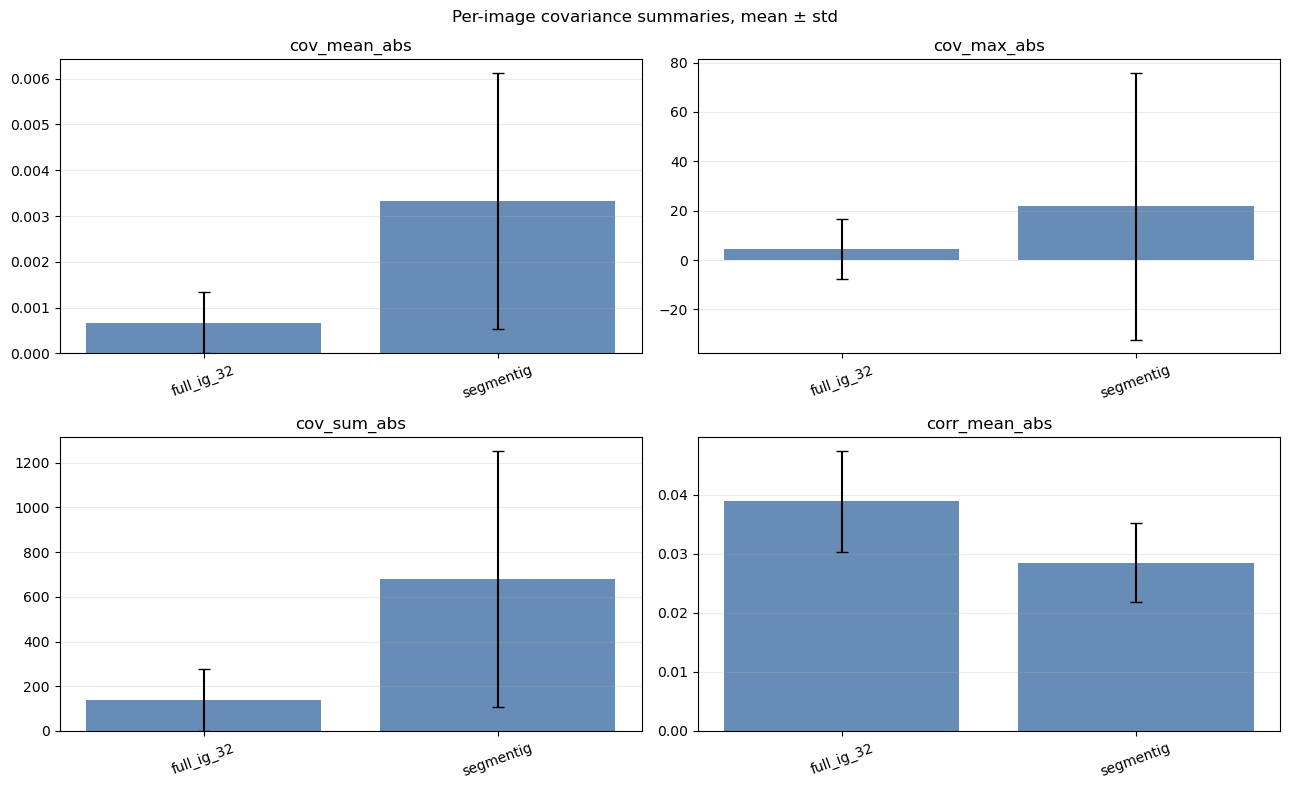

In [4]:
summary_cols = [
    "cov_mean",
    "cov_std",
    "cov_mean_abs",
    "cov_max_abs",
    "cov_sum_abs",
    "cov_positive_frac",
    "corr_mean_abs",
    "corr_positive_frac",
]

summary = cov_rows.groupby("method")[summary_cols].agg(["mean", "std", "count"])
display(summary)

fig = covariance.plot_covariance_overview(cov_rows)
plt.show()


## Success/fail разрез

Здесь тот же per-image summary, но отдельно для успешных и неуспешных атак.

cov_mean                   cov_std                  \
                        mean       std count      mean       std count   
method     success                                                       
full_ig_32 False    0.000054  0.000155   999  0.017655  0.034263   999   
           True     0.000069  0.000142  1000  0.019226  0.039232  1000   
segmentig  False    0.000213  0.000585   999  0.092184  0.182230   999   
           True     0.000244  0.000606  1000  0.084986  0.161532  1000   

                   cov_mean_abs                 cov_max_abs  ... cov_sum_abs  \
                           mean       std count        mean  ...       count   
method     success                                           ...               
full_ig_32 False       0.000657  0.000690   999    4.356641  ...         999   
           True        0.000690  0.000655  1000    4.879976  ...        1000   
segmentig  False       0.003376  0.002864   999   22.894136  ...         999   
           True        0.003270  0.002718  1000   20.607187  ...        1000   

                   cov_positive_frac                 corr_mean_abs            \
                                mean       std count          mean       std   
method     success                                                             
full_ig_32 False            0.031098  0.005121   999      0.038166  0.009475   
           True             0.031840  0.002639  1000      0.039601  0.007479   
segmentig  False            0.031414  0.005154   999      0.028494  0.007476   
           True             0.032136  0.002632  1000      0.028543  0.005884   

                         corr_positive_frac                  
                   count               mean       std count  
method     success                                           
full_ig_32 False     999           0.031106  0.005122   999  
           True     1000           0.031848  0.002640  1000  
segmentig  False     999           0.031415  0.005154   999  
           True     1000           0.032137  0.002632  1000  

[4 rows x 24 columns]

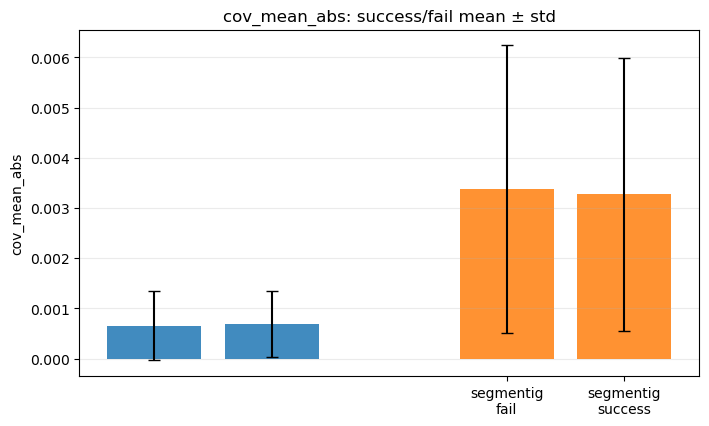

In [5]:
success_summary = cov_rows.groupby(["method", "success"])[summary_cols].agg(["mean", "std", "count"])
display(success_summary)

metric = "cov_mean_abs"
plot_df = cov_rows.copy()
labels = {False: "fail", True: "success"}
fig, ax = plt.subplots(figsize=(8, 4.5))
for idx, (method, sub) in enumerate(plot_df.groupby("method")):
    stats = sub.groupby("success")[metric].agg(["mean", "std"]).reindex([False, True])
    x = [idx * 3, idx * 3 + 1]
    ax.bar(x, stats["mean"], yerr=stats["std"], capsize=4, alpha=0.85, label=method)
    ax.set_xticks(x, [f"{method}\n{labels[v]}" for v in [False, True]])
ax.set_ylabel(metric)
ax.set_title(f"{metric}: success/fail mean ± std")
ax.grid(axis="y", alpha=0.25)
plt.show()


## Распределение значений covariance

Для полного датасета не грузим все нейроны всех картинок в RAM: из каждой картинки берётся random sample нейронов, затем строится pooled density.

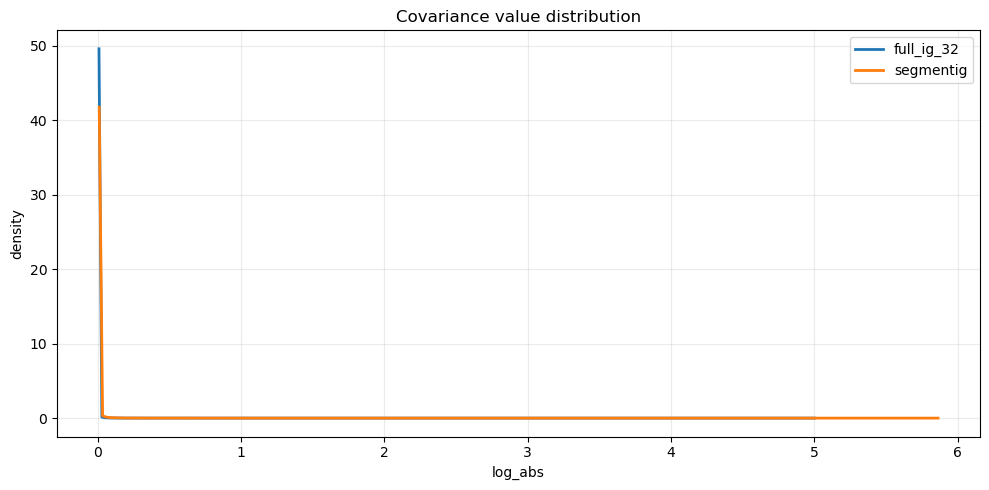

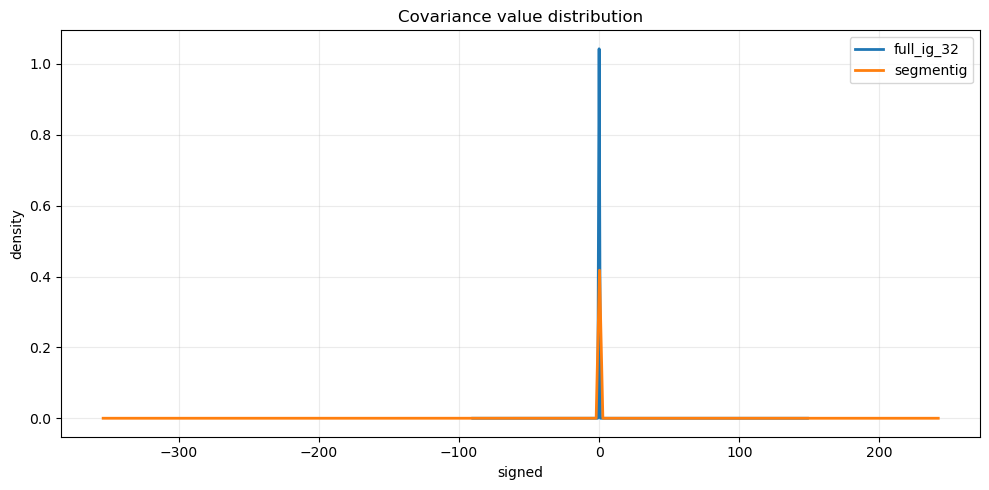

In [6]:
dist_abs = covariance.aggregate_covariance_distribution(
    cov_rows,
    bins=250,
    value_mode="log_abs",
    sample_per_image=20000,
    seed=13,
)
fig = covariance.plot_covariance_distributions(dist_abs)
plt.show()

dist_signed = covariance.aggregate_covariance_distribution(
    cov_rows,
    bins=250,
    value_mode="signed",
    sample_per_image=20000,
    seed=13,
)
fig = covariance.plot_covariance_distributions(dist_signed)
plt.show()


### Окрестность нуля

Signed distribution сильно доминируется редкими хвостами. Ниже строим zoom около нуля: сначала берём sample нейронов из каждой картинки, потом показываем центральное окно по abs(covariance) и ECDF.


,mean,std,min,max,count
method,,,,,
full_ig_32,0.000072,0.054371,-90.625,149.125,39980000
segmentig,0.000247,0.176337,-355.000,243.125,39980000


method
full_ig_32    0.938593
segmentig     0.938595
Name: exact_zero_fraction, dtype: float64

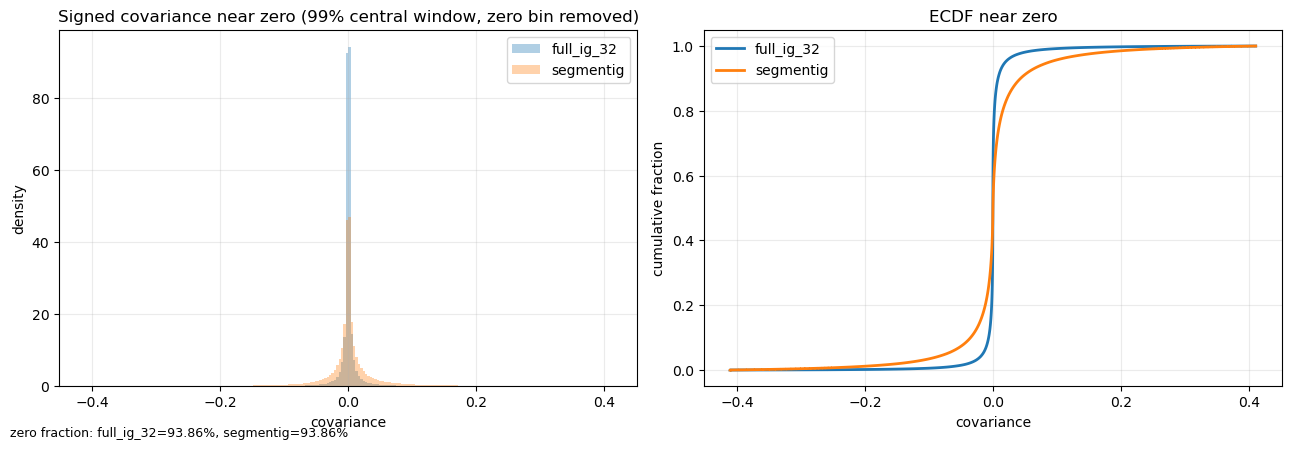

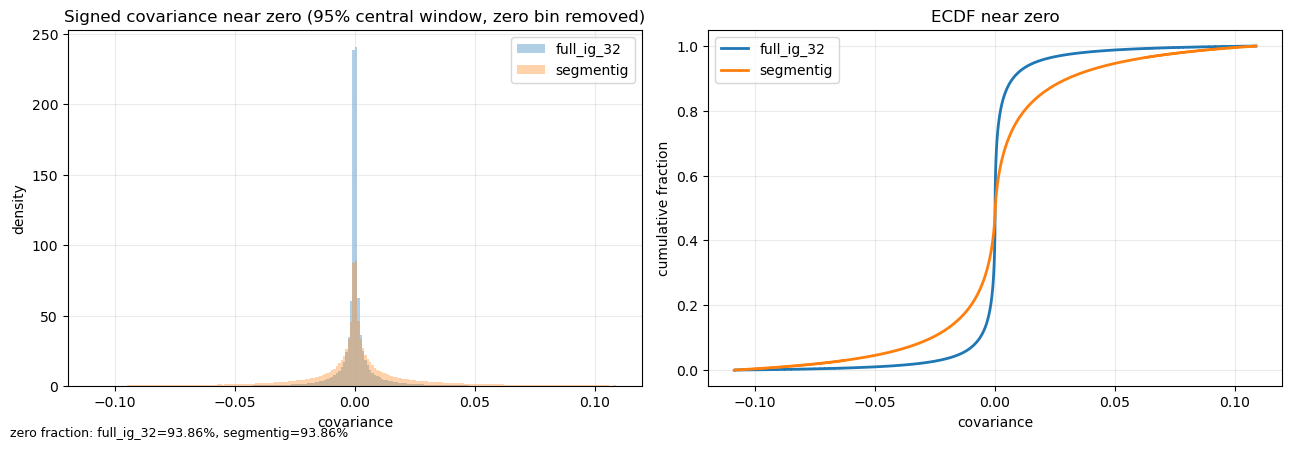

In [7]:
cov_signed_values = covariance.sample_covariance_values(
    cov_rows,
    value_mode="signed",
    sample_per_image=20000,
    seed=13,
)
display(cov_signed_values.groupby("method")["value"].agg(["mean", "std", "min", "max", "count"]))
zero_share = cov_signed_values.assign(is_zero=cov_signed_values["value"].eq(0.0)).groupby("method")["is_zero"].mean()
display(zero_share.rename("exact_zero_fraction"))

fig = covariance.plot_covariance_zero_zoom(cov_signed_values, q=99.0, bins=220, drop_zeros=True)
plt.show()

fig = covariance.plot_covariance_zero_zoom(cov_signed_values, q=95.0, bins=220, drop_zeros=True)
plt.show()


## Агрегация по рангам нейронов

Для каждой картинки сортируем нейроны по `|covariance|`, режем отсортированный список на равные rank-бины и усредняем значения внутри бинов. Затем усредняем rank-кривые по картинкам, показывая `mean ± std`.

,method,rank_bin,rank_frac,mean,std,n
0,segmentig,1,0.0025,0.453894,0.473334,1999
1,segmentig,2,0.0075,0.083553,0.044876,1999
2,segmentig,3,0.0125,0.045565,0.023053,1999
3,segmentig,4,0.0175,0.028499,0.014058,1999
4,segmentig,5,0.0225,0.018823,0.009148,1999


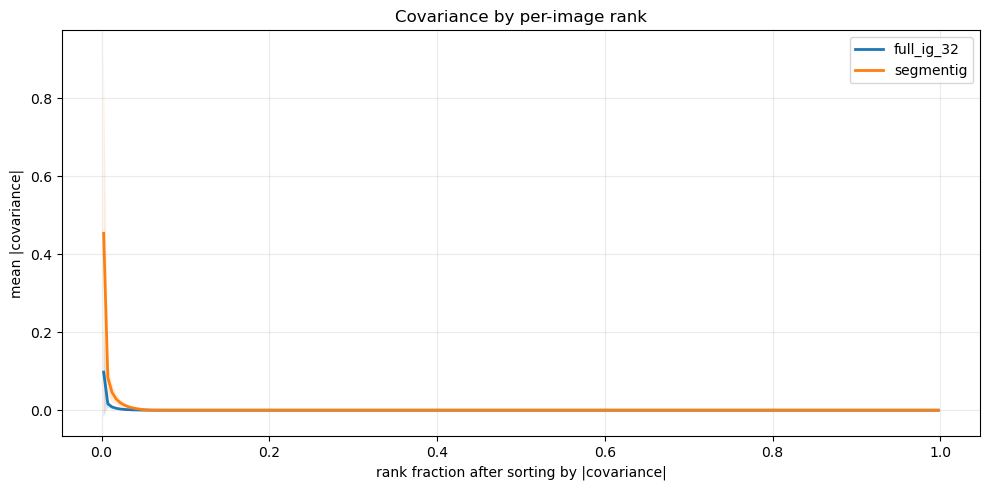

In [8]:
rank_curves = []
for method in cov_rows["method"].dropna().unique():
    rank_curves.append(
        covariance.aggregate_covariance_by_rank(
            cov_rows,
            method=method,
            n_bins=200,
            signed=False,
        )
    )
rank_df = pd.concat(rank_curves, ignore_index=True) if rank_curves else pd.DataFrame()
display(rank_df.head())

fig = covariance.plot_covariance_rank_curves(rank_df)
plt.show()


## Масса covariance в top-k процентах

Дополнительно смотрим, насколько сильно `|covariance|` концентрируется в верхних 1/5/10% нейронов. Это быстрый способ понять, доминируют ли несколько компонент.

top_1pct_mass_frac                 top_5pct_mass_frac            \
                         mean       std count               mean       std   
method                                                                       
full_ig_32           0.808464  0.108584  1999           0.983007  0.123407   
segmentig            0.765288  0.109077  1999           0.981737  0.123248   

                 top_10pct_mass_frac                  
           count                mean       std count  
method                                                
full_ig_32  1999            0.984492  0.123592  1999  
segmentig   1999            0.984492  0.123592  1999

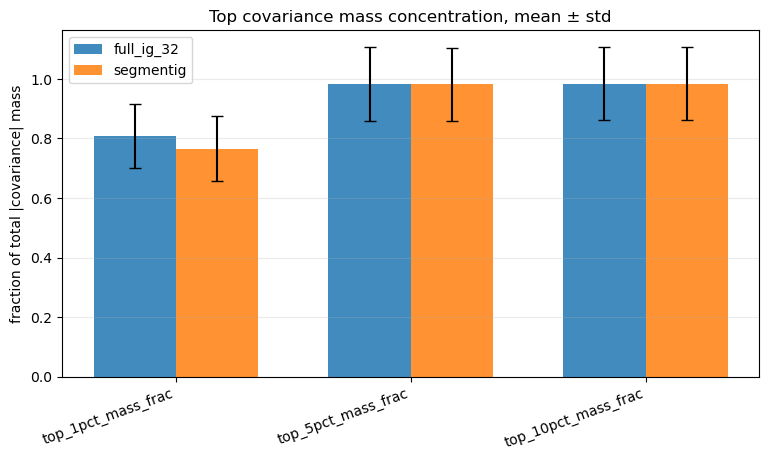

In [9]:
def covariance_top_mass_table(rows, fractions=(0.01, 0.05, 0.10)):
    import numpy as np
    out = []
    for _, row in rows.iterrows():
        with np.load(row["cache_path"], allow_pickle=False) as data:
            v = np.abs(data["cov_chw"].astype("float32", copy=False).reshape(-1))
        total = float(v.sum() + 1e-12)
        order = np.argsort(v)[::-1]
        rec = {"method": row["method"], "path": row["path"], "success": row["success"], "drop": row["drop"]}
        for frac in fractions:
            k = max(1, int(round(v.size * float(frac))))
            rec[f"top_{int(frac * 100)}pct_mass_frac"] = float(v[order[:k]].sum() / total)
        out.append(rec)
    return pd.DataFrame(out)

top_mass_df = covariance_top_mass_table(cov_rows)
mass_cols = [col for col in top_mass_df.columns if col.startswith("top_")]
display(top_mass_df.groupby("method")[mass_cols].agg(["mean", "std", "count"]))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(mass_cols))
width = 0.35
for offset, (method, sub) in enumerate(top_mass_df.groupby("method")):
    means = sub[mass_cols].mean().to_numpy()
    stds = sub[mass_cols].std().to_numpy()
    ax.bar([i + offset * width for i in x], means, width=width, yerr=stds, capsize=4, label=method, alpha=0.85)
ax.set_xticks([i + width / 2 for i in x], mass_cols, rotation=20, ha="right")
ax.set_ylabel("fraction of total |covariance| mass")
ax.set_title("Top covariance mass concentration, mean ± std")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.show()


## Метрики по low/high covariance нейронам

Начиная с этого раздела используем только `full_ig_32` covariance. Делим нейроны по `|covariance|`: пороги считаются как `mean_nonzero_abs + k * std_nonzero_abs` для `k = 0.5, 1, 2, 3`. Нули не участвуют в оценке mean/std, но при применении порога попадают в low-группу. Метрики считаются отдельно для low/high-групп и кэшируются как derived pickle.

In [10]:
cov_rows_full_ig_32 = cov_rows[cov_rows["method"].astype(str) == "full_ig_32"].copy()
if cov_rows_full_ig_32.empty:
    raise RuntimeError("No full_ig_32 covariance rows found. Run the covariance compute cell for full_ig_32 first.")
print(f"full_ig_32 covariance rows={len(cov_rows_full_ig_32)} / all rows={len(cov_rows)}")

cov_split_result = covariance.compute_or_load_covariance_split_metrics(
    exp,
    cov_rows_full_ig_32,
    selected_examples,
    sigmas=(0.5, 1.0, 2.0, 3.0),
    layer_name=config.target_layer,
    top_percent=5.0,
    rank_bins=100,
    include_spatial=True,
    zero_eps=0.0,
    force=False,
)

cov_split_rows = cov_split_result["rows"]
cov_split_quality = cov_split_result["quality"]
cov_split_thresholds = cov_split_result["thresholds"]
cov_split_skipped = cov_split_result["skipped"]

print("loaded_from_cache=" + str(cov_split_result["loaded_from_cache"]))
print("cache_path=" + str(cov_split_result["cache_path"]))
print(f"metric rows={len(cov_split_rows)}, quality rows={len(cov_split_quality)}, skipped={len(cov_split_skipped)}")
display(cov_split_thresholds)
if len(cov_split_skipped):
    display(cov_split_skipped.head(20))
display(cov_split_quality.head(40))

full_ig_32 covariance rows=1999 / all rows=3998
loaded_from_cache=True
cache_path=new_experiments/outputs/patch_success_analysis/cache/covariance_split_metrics/covariance_split_metrics_e1539f9dfef2cd7f.pkl
metric rows=15992, quality rows=1936, skipped=1


,method,sigma,threshold,mean_abs_nonzero,std_abs_nonzero,nonzero_count,total_count,zero_frac
0,full_ig_32,0.5,0.093882,0.01097,0.165825,25140193.0,409395200.0,0.938592
1,full_ig_32,1.0,0.176795,0.01097,0.165825,25140193.0,409395200.0,0.938592
2,full_ig_32,2.0,0.342619,0.01097,0.165825,25140193.0,409395200.0,0.938592
3,full_ig_32,3.0,0.508444,0.01097,0.165825,25140193.0,409395200.0,0.938592


,path,reason
0,../datasets/COCO_people/03520_train2017_image1...,missing covariance row


,metric,roc_auc,best_accuracy,best_threshold,best_direction,cov_method,sigma,cov_group,roc_auc_effective
0,attack_energy_top5_importance_sum,0.687609,0.653327,2900.572881,1,full_ig_32,3.0,low,0.687609
1,attack_energy_top5_importance_sum,0.687469,0.653327,2901.834946,1,full_ig_32,2.0,low,0.687469
2,attack_energy_top5_importance_sum,0.687118,0.653327,2894.842348,1,full_ig_32,1.0,low,0.687118
3,attack_energy_top10_0p1bin_linear_sum,0.683282,0.652826,2750.438458,1,full_ig_32,3.0,low,0.683282
4,attack_energy_top10_0p1bin_linear_sum,0.683010,0.652826,2746.766164,1,full_ig_32,2.0,low,0.683010
5,attack_energy_top10_0p1bin_linear_sum,0.682609,0.652826,2750.474993,1,full_ig_32,1.0,low,0.682609
6,masked_hand_rank_ratio_top5_top25,0.686625,0.650825,0.228433,1,full_ig_32,1.0,low,0.686625
7,attack_energy_top5_importance_sum,0.686404,0.650825,2680.436662,1,full_ig_32,0.5,low,0.686404
8,masked_hand_rank_ratio_top5_top25,0.686374,0.650825,0.228778,1,full_ig_32,0.5,low,0.686374
9,masked_hand_rank_ratio_top5_top25,0.686371,0.650825,0.229712,1,full_ig_32,2.0,low,0.686371


## Общие графики качества

Показываем лучшие комбинации `metric + covariance method + sigma threshold + low/high group` отдельно по validation accuracy и direction-aware ROC-AUC. Сырой `roc_auc` остаётся в таблице, а для ранжирования ROC используем `roc_auc_effective = max(auc, 1-auc)`, потому что часть метрик работает в обратном направлении.

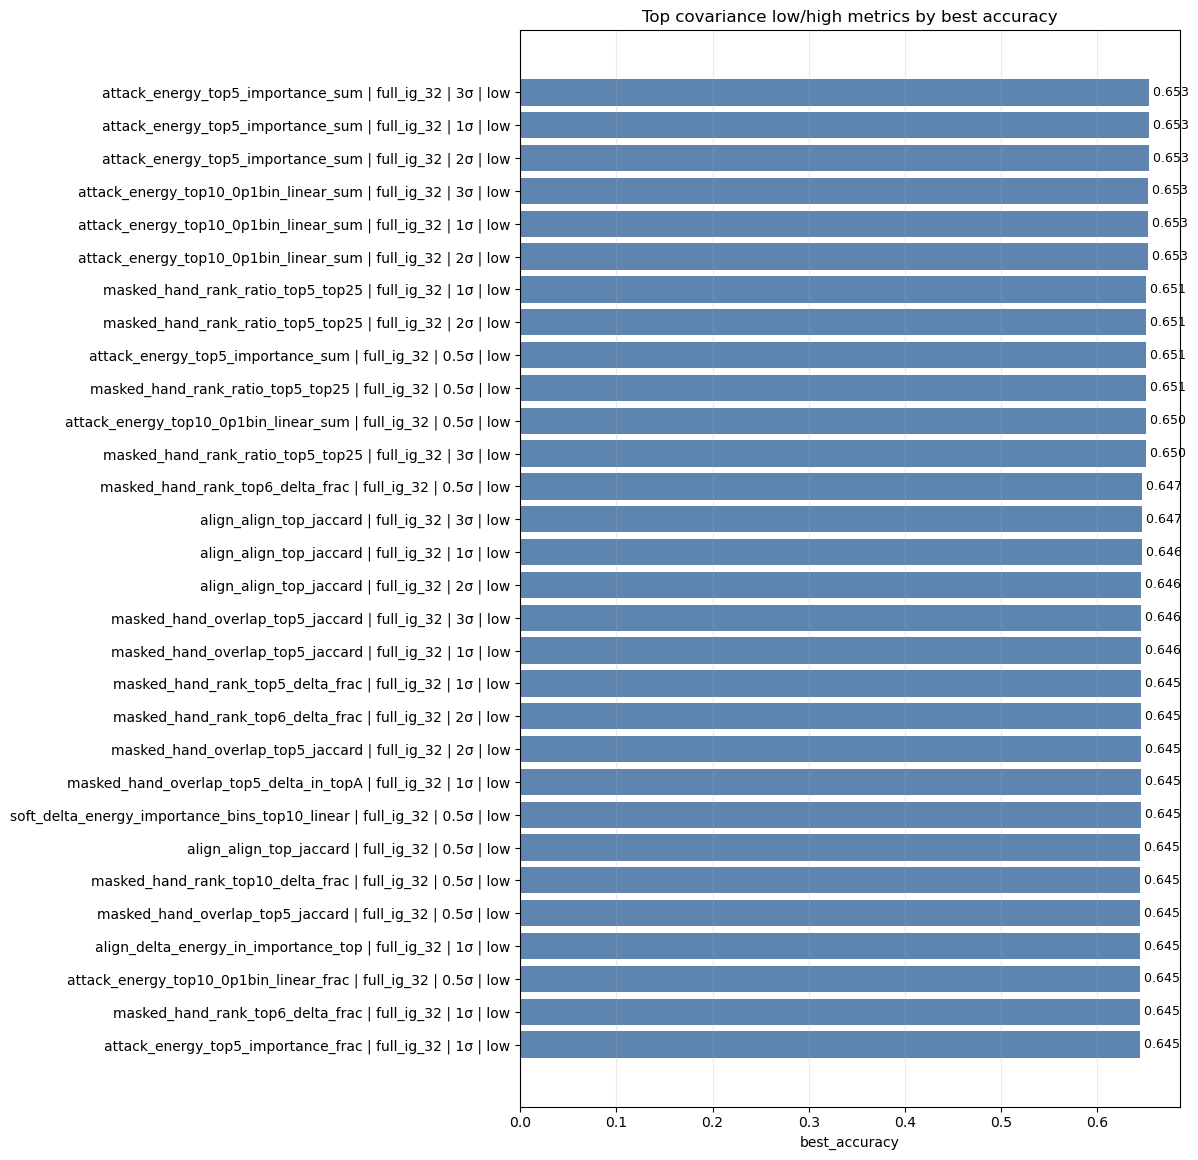

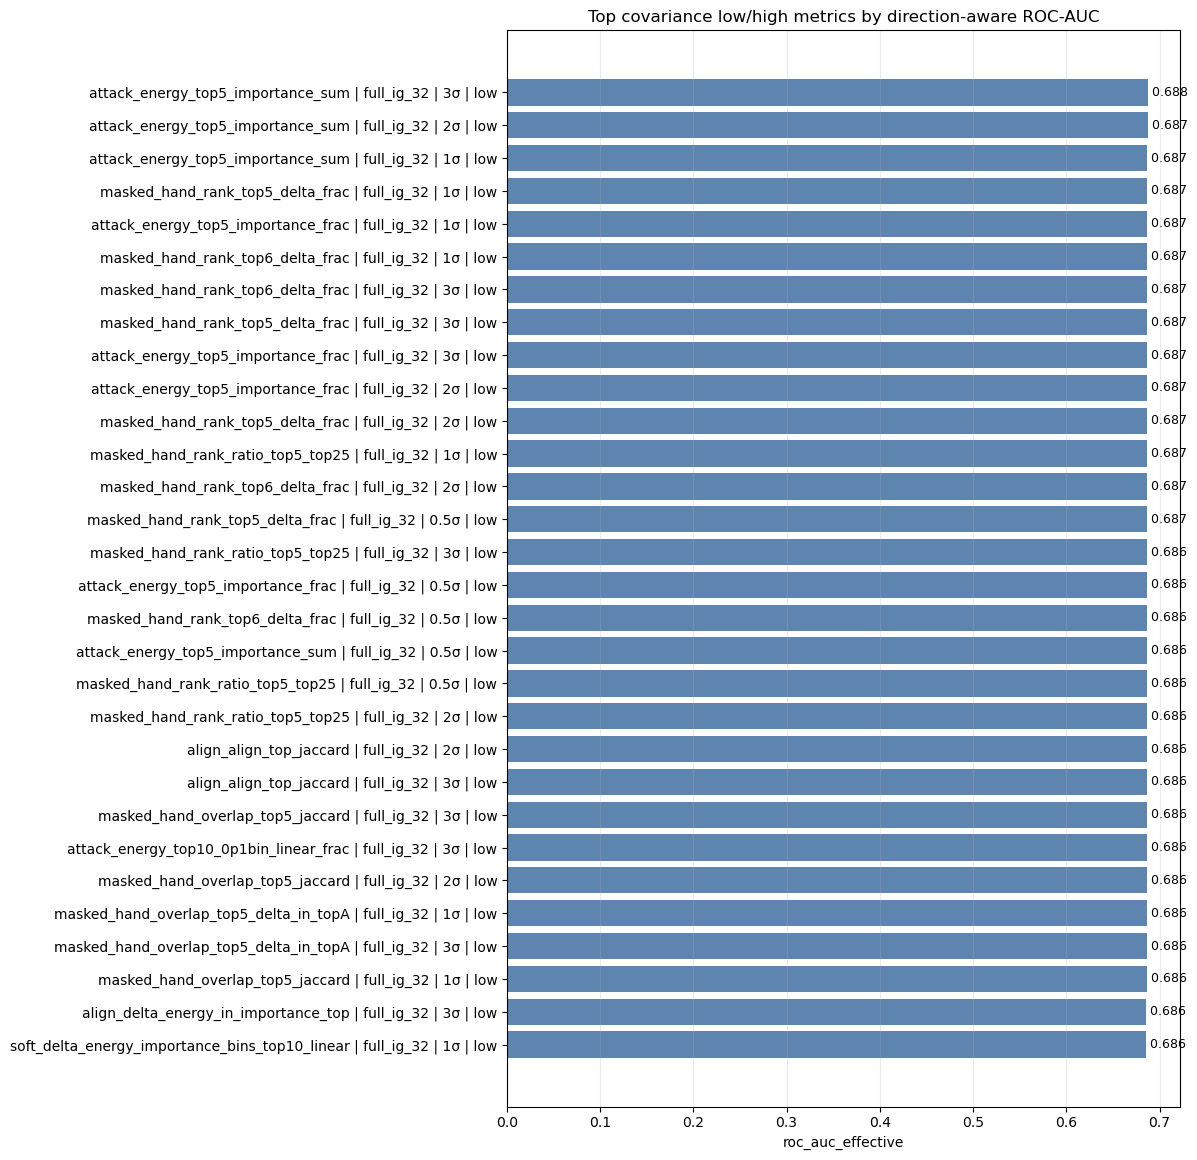

In [11]:
fig = covariance.plot_covariance_split_quality_overview(
    cov_split_quality,
    score_col="best_accuracy",
    top_n=30,
    title="Top covariance low/high metrics by best accuracy",
)
plt.show()

fig = covariance.plot_covariance_split_quality_overview(
    cov_split_quality,
    score_col="roc_auc_effective",
    top_n=30,
    title="Top covariance low/high metrics by direction-aware ROC-AUC",
)
plt.show()

## Индивидуальные графики лучших метрик

Для top-метрик строим привычную визуализацию: распределения success/fail и ROC-кривую с best accuracy.

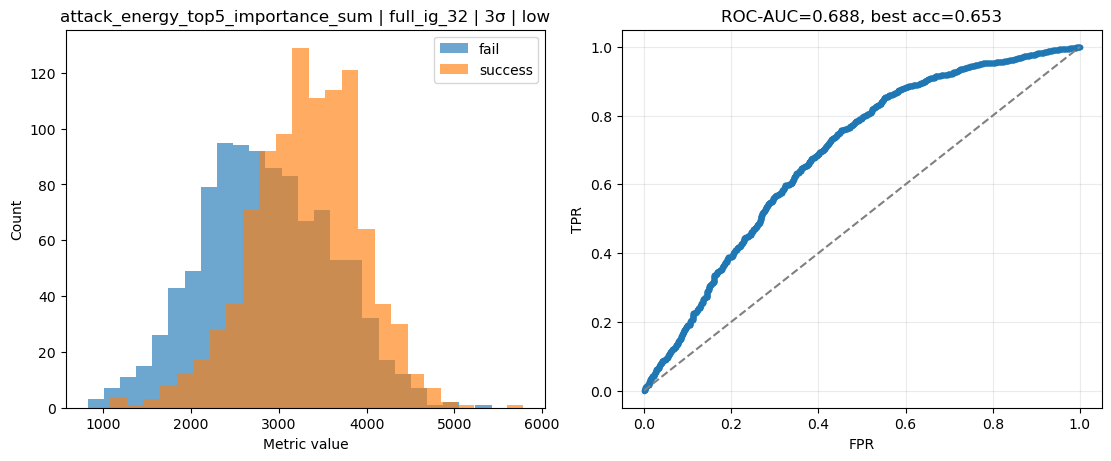

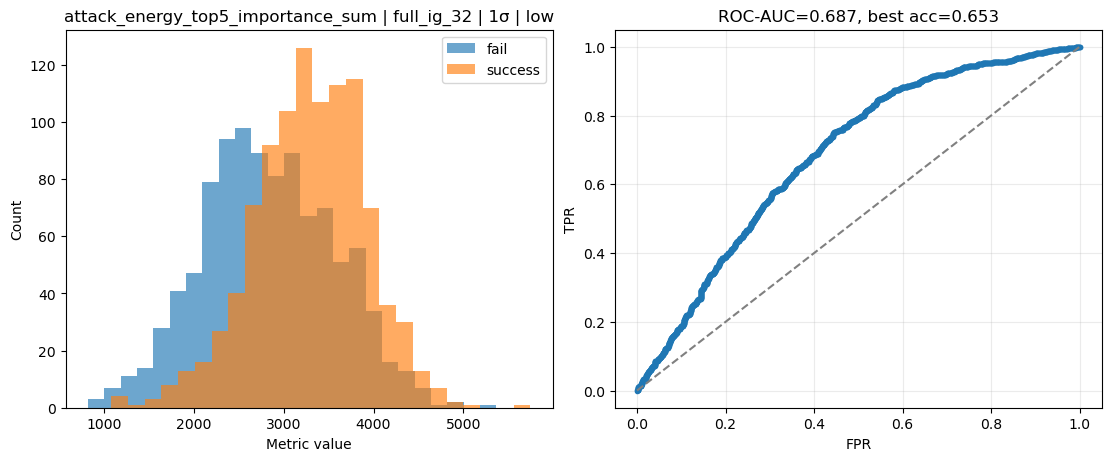

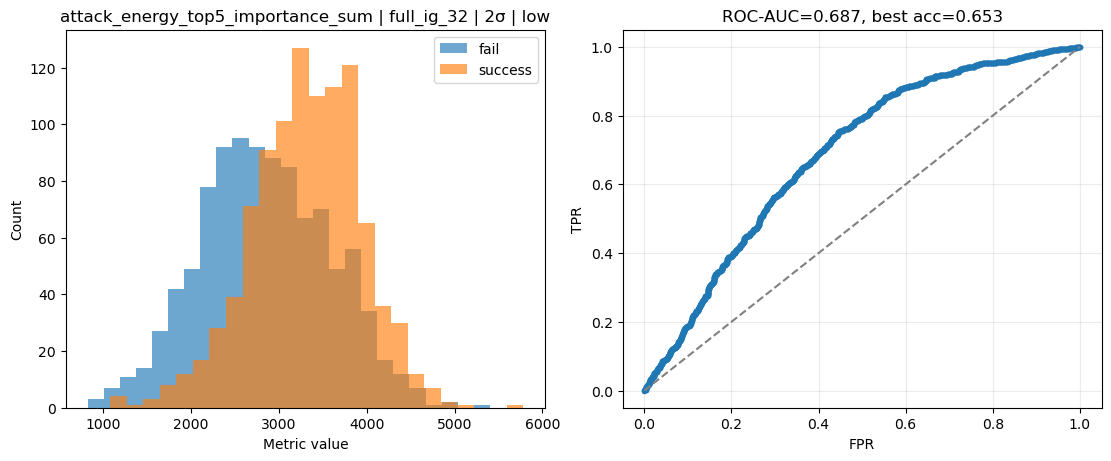

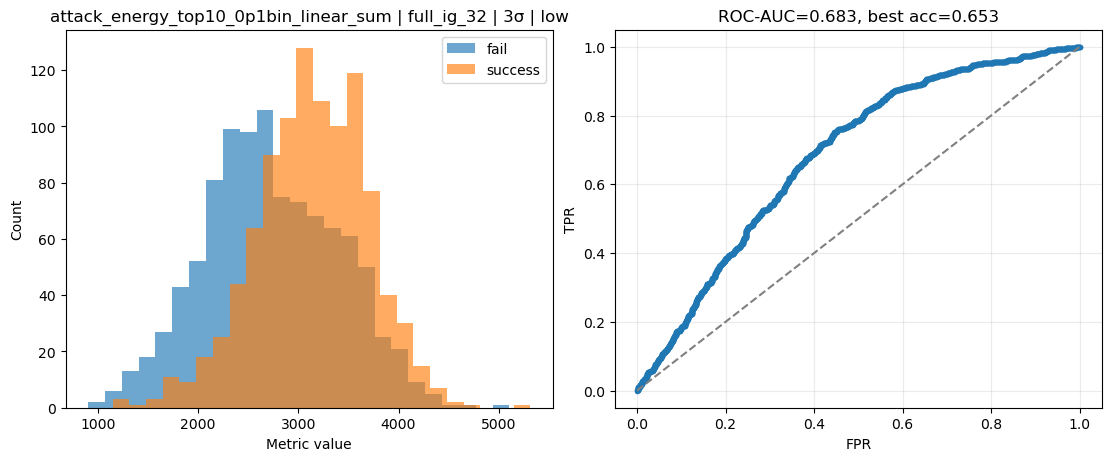

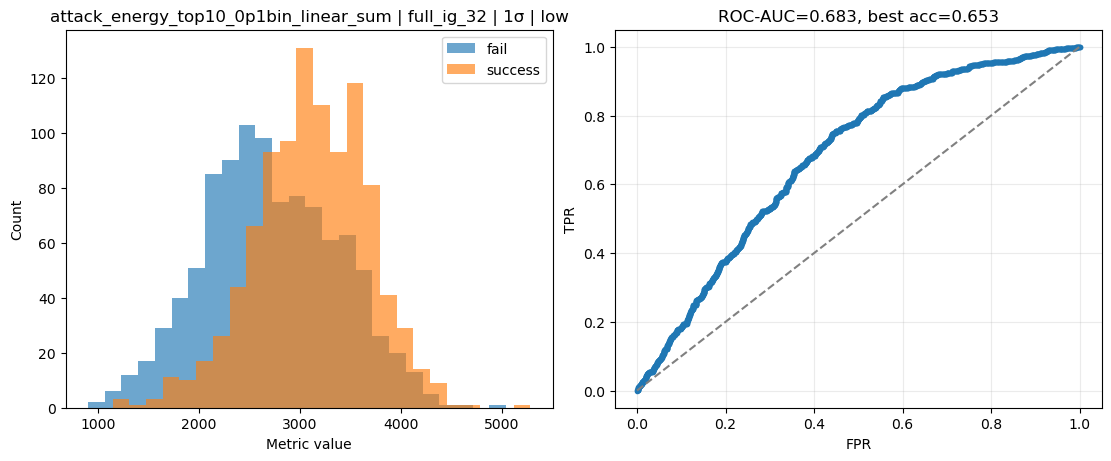

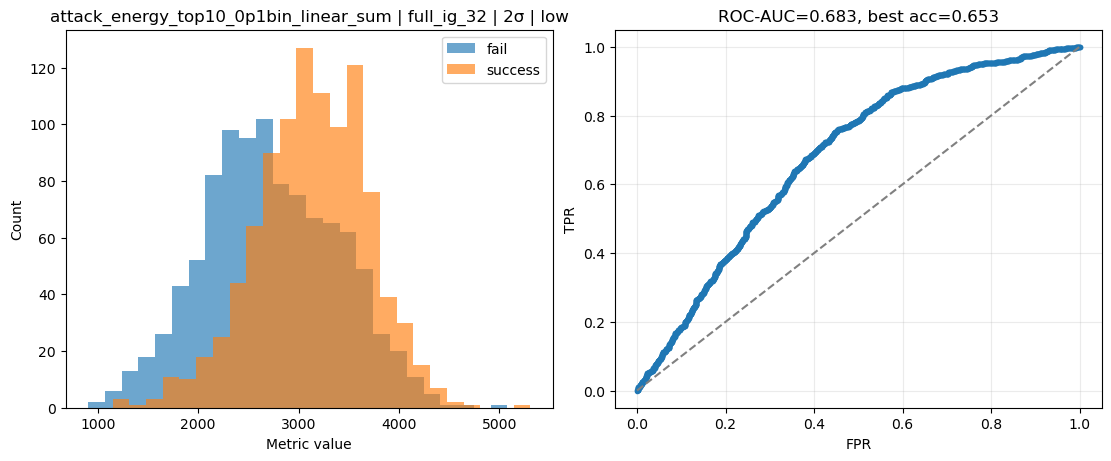

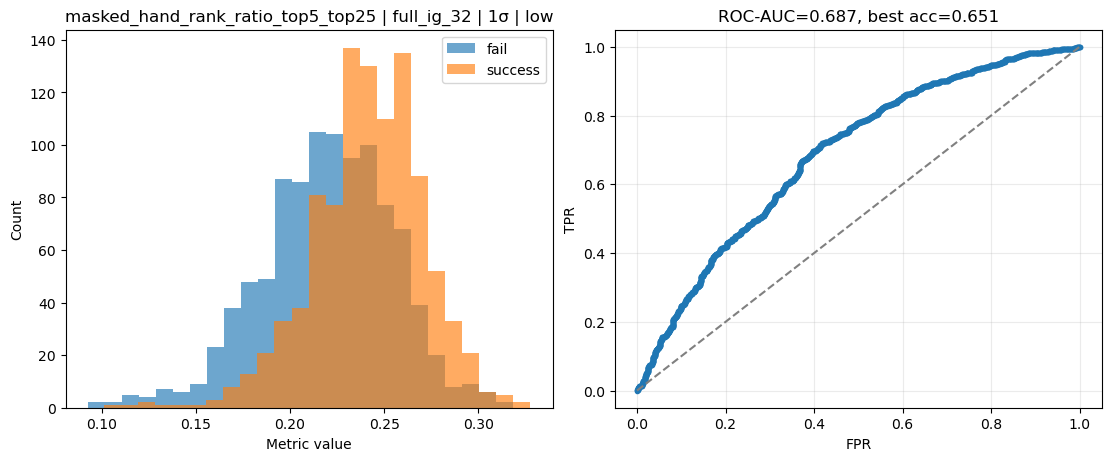

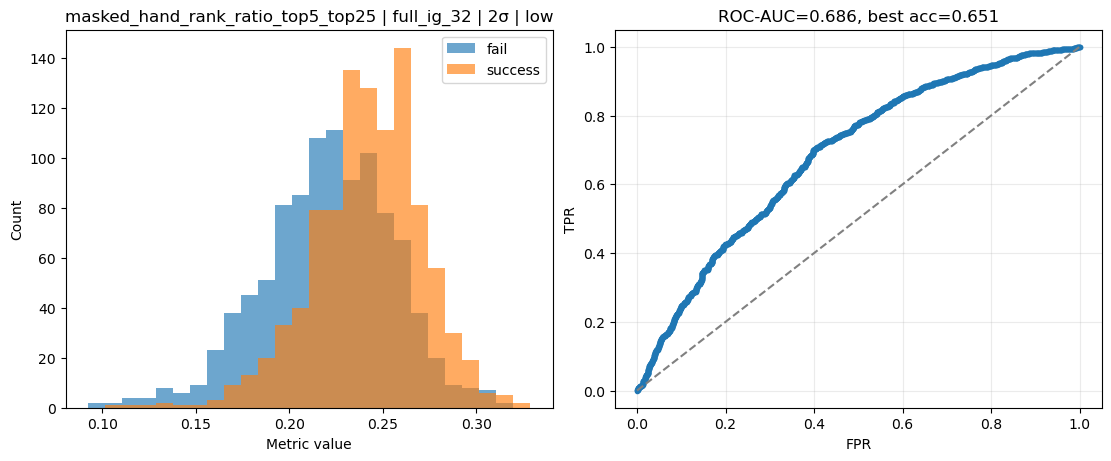

In [12]:
detail_figs = covariance.plot_best_covariance_split_metric_details(
    cov_split_rows,
    cov_split_quality,
    top_n=8,
    score_col="best_accuracy",
)
for fig in detail_figs:
    plt.show(fig)

## Focus metrics: top-importance attack energy

Здесь отдельно выводим метрики, которые раньше выглядели наиболее осмысленно: доля энергии атаки в top 5% самых важных нейронов и weighted top 10% по 0.1%-бинам с линейным убыванием. Для каждой fraction-метрики рядом есть raw-вариант без деления на total attack energy: это чистая сумма `|delta|` в выбранных нейронах/бинах.

overall loaded_from_cache=True
overall cache_path=new_experiments/outputs/patch_success_analysis/cache/importance_energy_focus_metrics/importance_energy_focus_metrics_c61537ad82967890.pkl


,path,reason
0,../datasets/COCO_people/03520_train2017_image1...,missing layer_maps cache


,metric,variant,variant_type,best_accuracy,roc_auc,roc_auc_effective,best_threshold,best_direction,cov_method,sigma,cov_group
4,attack_energy_top5_importance_sum,full_ig_32 | 3σ | low,low,0.653327,0.687609,0.687609,2900.572881,1,full_ig_32,3.0,low
5,attack_energy_top5_importance_sum,full_ig_32 | 2σ | low,low,0.653327,0.687469,0.687469,2901.834946,1,full_ig_32,2.0,low
6,attack_energy_top5_importance_sum,full_ig_32 | 1σ | low,low,0.653327,0.687118,0.687118,2894.842348,1,full_ig_32,1.0,low
7,attack_energy_top10_0p1bin_linear_sum,full_ig_32 | 3σ | low,low,0.652826,0.683282,0.683282,2750.438458,1,full_ig_32,3.0,low
8,attack_energy_top10_0p1bin_linear_sum,full_ig_32 | 2σ | low,low,0.652826,0.683010,0.683010,2746.766164,1,full_ig_32,2.0,low
9,attack_energy_top10_0p1bin_linear_sum,full_ig_32 | 1σ | low,low,0.652826,0.682609,0.682609,2750.474993,1,full_ig_32,1.0,low
0,attack_energy_top10_0p1bin_linear_sum,overall,overall,0.652326,0.683577,0.683577,2756.279287,1,none,NaN,none
1,attack_energy_top5_importance_sum,overall,overall,0.651326,0.687814,0.687814,2905.076392,1,none,NaN,none
10,attack_energy_top5_importance_sum,full_ig_32 | 0.5σ | low,low,0.650825,0.686404,0.686404,2680.436662,1,full_ig_32,0.5,low
11,attack_energy_top10_0p1bin_linear_sum,full_ig_32 | 0.5σ | low,low,0.650325,0.681814,0.681814,2728.484618,1,full_ig_32,0.5,low


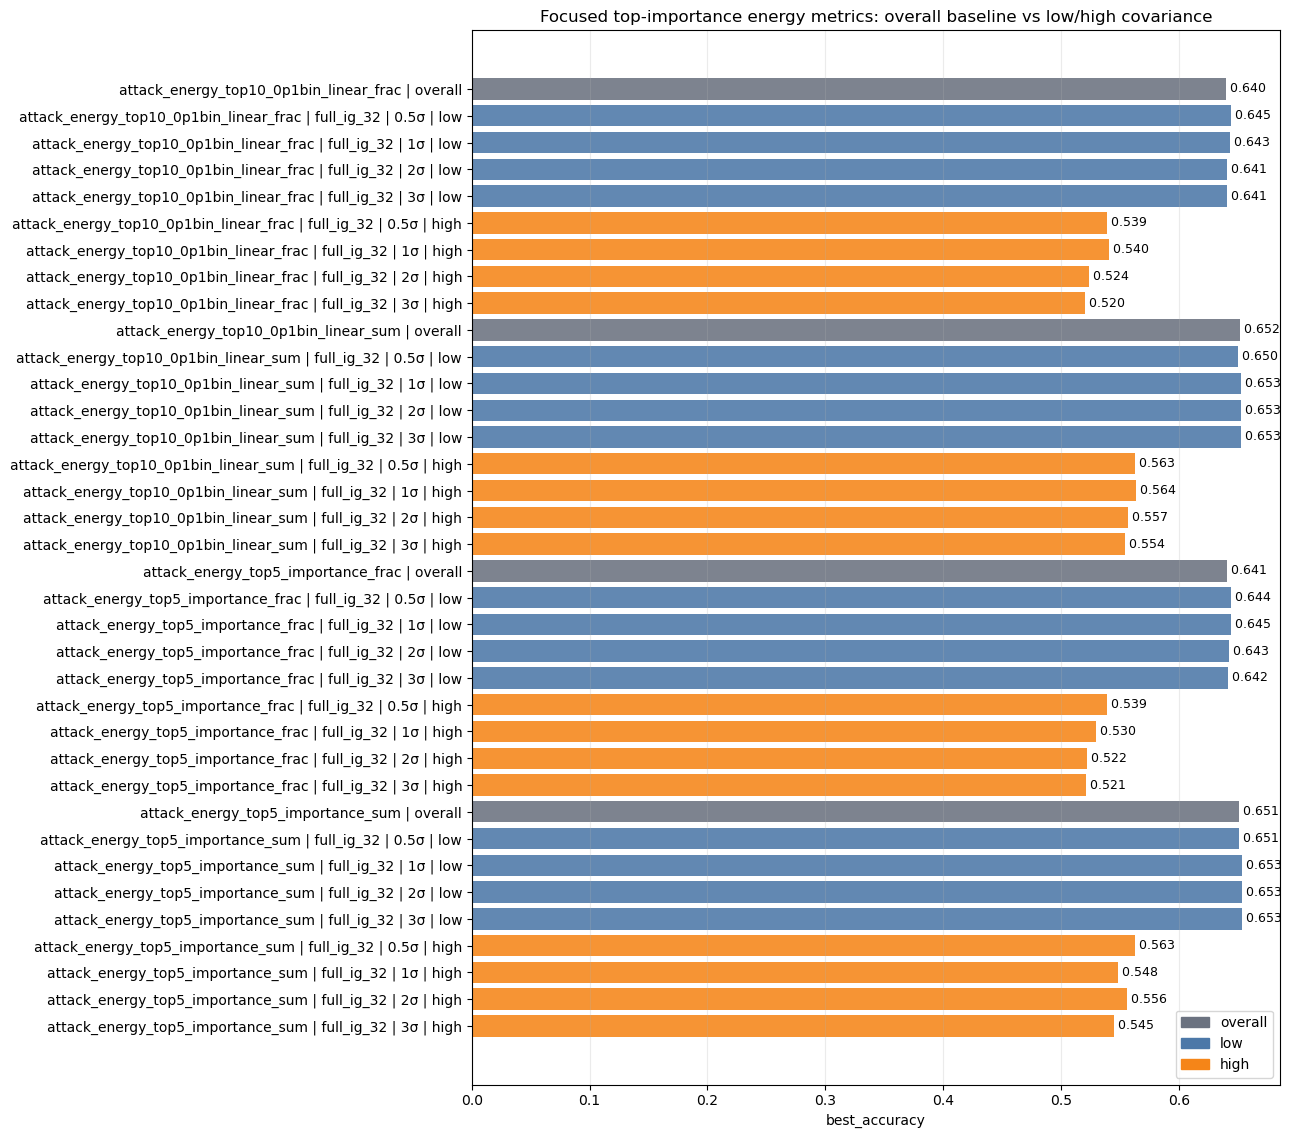

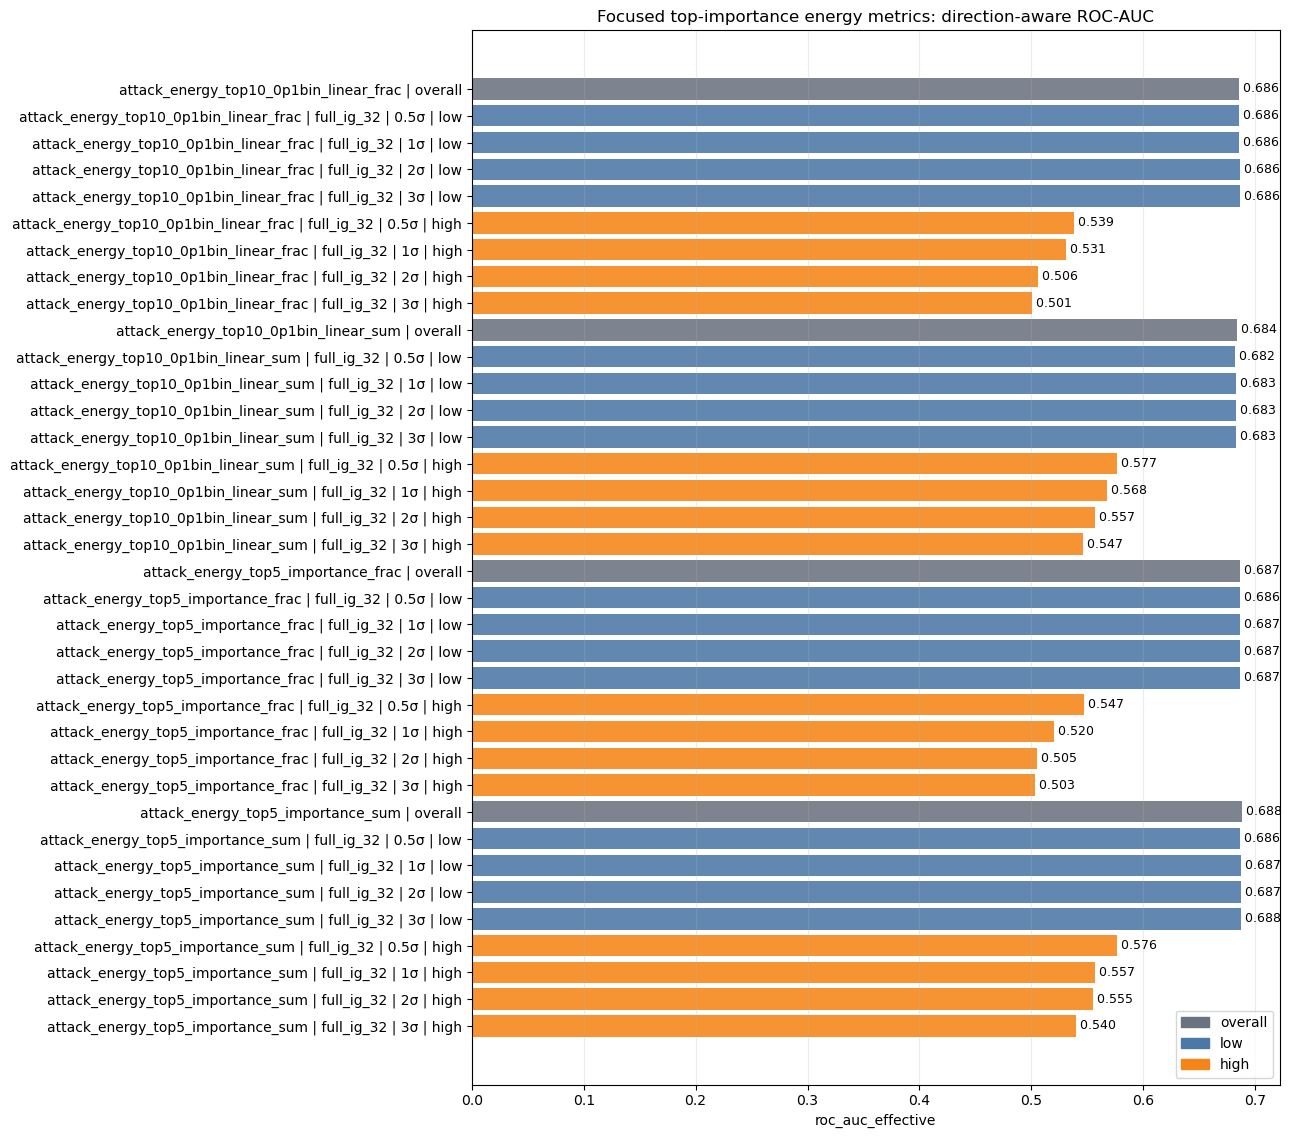

In [13]:
focus_metric_cols = [
    "attack_energy_top5_importance_frac",
    "attack_energy_top5_importance_sum",
    "attack_energy_top10_0p1bin_linear_frac",
    "attack_energy_top10_0p1bin_linear_sum",
]

focus_overall_result = covariance.compute_or_load_importance_energy_focus_metrics(
    exp,
    selected_examples,
    layer_name=config.target_layer,
    force=False,
)
focus_overall_rows = focus_overall_result["rows"]
focus_overall_quality = focus_overall_result["quality"]
focus_overall_skipped = focus_overall_result["skipped"]

print("overall loaded_from_cache=" + str(focus_overall_result["loaded_from_cache"]))
print("overall cache_path=" + str(focus_overall_result["cache_path"]))
if len(focus_overall_skipped):
    display(focus_overall_skipped.head(20))

focus_split_quality = (
    cov_split_quality[cov_split_quality["metric"].isin(focus_metric_cols)]
    .sort_values(["best_accuracy", "roc_auc_effective"], ascending=False)
    .reset_index(drop=True)
)
focus_quality_comparison = covariance.focus_quality_comparison_table(
    focus_split_quality,
    focus_overall_quality,
    metric_cols=focus_metric_cols,
)

display(focus_quality_comparison.sort_values(["best_accuracy", "roc_auc_effective"], ascending=False))

fig = covariance.plot_focus_quality_comparison_bars(
    focus_quality_comparison,
    score_col="best_accuracy",
    title="Focused top-importance energy metrics: overall baseline vs low/high covariance",
)
plt.show()

fig = covariance.plot_focus_quality_comparison_bars(
    focus_quality_comparison,
    score_col="roc_auc_effective",
    title="Focused top-importance energy metrics: direction-aware ROC-AUC",
)
plt.show()

## Overall focus metrics without covariance split

Та же пара ratio/raw метрик, но без разделения нейронов по covariance. Это baseline: насколько сами SegmentIG-ранги важности объясняют success/fail без low/high covariance фильтра.

In [14]:
if "focus_overall_result" not in globals():
    focus_overall_result = covariance.compute_or_load_importance_energy_focus_metrics(
        exp,
        selected_examples,
        layer_name=config.target_layer,
        force=False,
    )
    focus_overall_rows = focus_overall_result["rows"]
    focus_overall_quality = focus_overall_result["quality"]
    focus_overall_skipped = focus_overall_result["skipped"]

print("loaded_from_cache=" + str(focus_overall_result["loaded_from_cache"]))
print("cache_path=" + str(focus_overall_result["cache_path"]))
print(f"rows={len(focus_overall_rows)}, quality rows={len(focus_overall_quality)}, skipped={len(focus_overall_skipped)}")
if len(focus_overall_skipped):
    display(focus_overall_skipped.head(20))
display(focus_overall_quality)

loaded_from_cache=True
cache_path=new_experiments/outputs/patch_success_analysis/cache/importance_energy_focus_metrics/importance_energy_focus_metrics_c61537ad82967890.pkl
rows=1999, quality rows=5, skipped=1


,path,reason
0,../datasets/COCO_people/03520_train2017_image1...,missing layer_maps cache


,metric,roc_auc,best_accuracy,best_threshold,best_direction,roc_auc_effective
0,attack_energy_top10_0p1bin_linear_sum,0.683577,0.652326,2756.279287,1,0.683577
1,attack_energy_top5_importance_sum,0.687814,0.651326,2905.076392,1,0.687814
2,attack_energy_top5_importance_frac,0.686688,0.640820,0.058074,1,0.686688
3,attack_energy_top10_0p1bin_linear_frac,0.685925,0.639820,0.053916,1,0.685925
4,attack_energy_total_abs_sum,0.597643,0.587794,48514.756478,1,0.597643


## Raw sum vs fraction

Проверяем, несёт ли нормировка на total attack energy отдельный сигнал: по оси X ratio/fraction, по оси Y тот же numerator без деления.

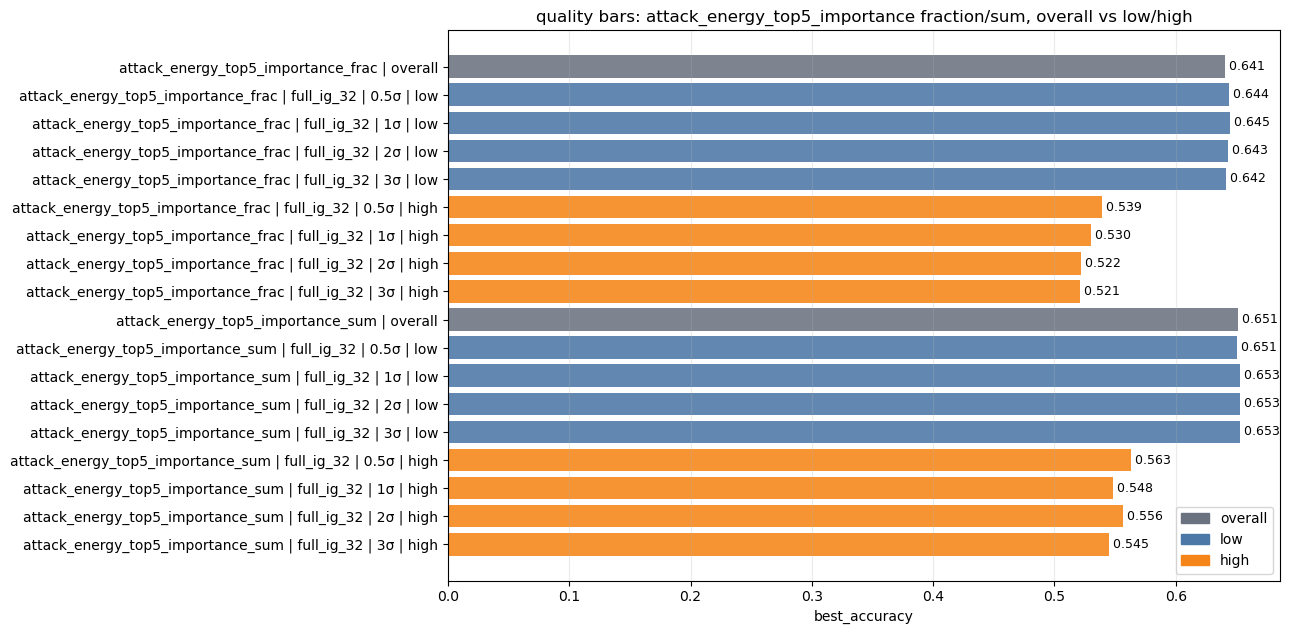

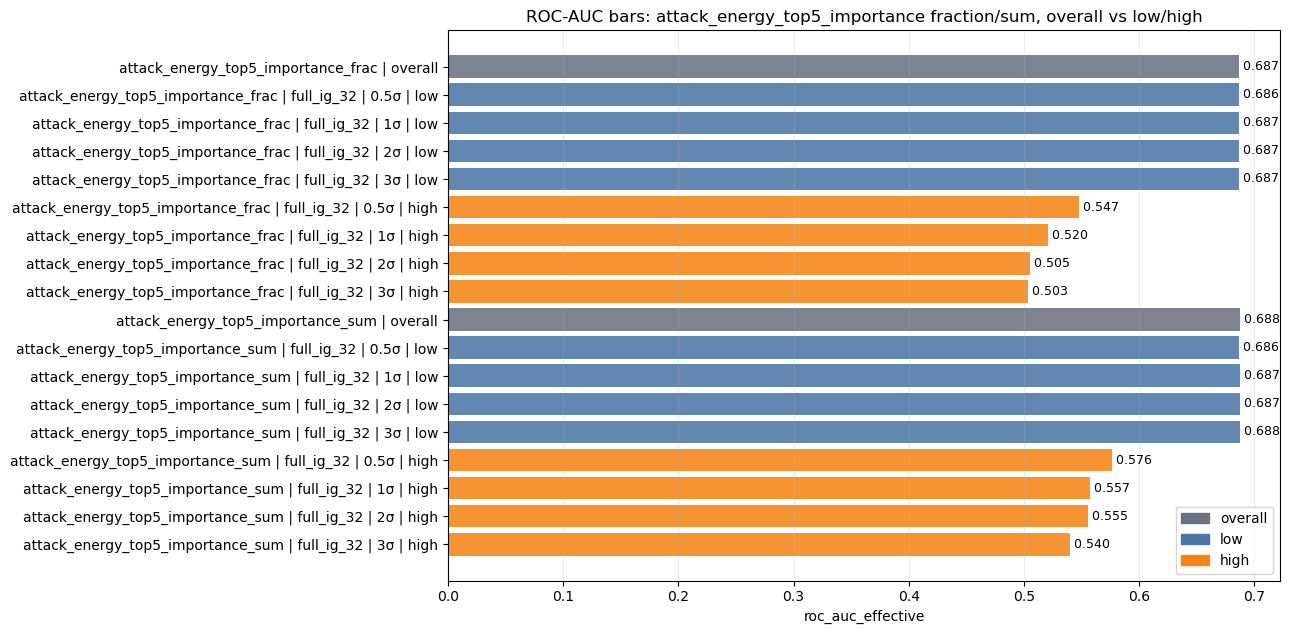

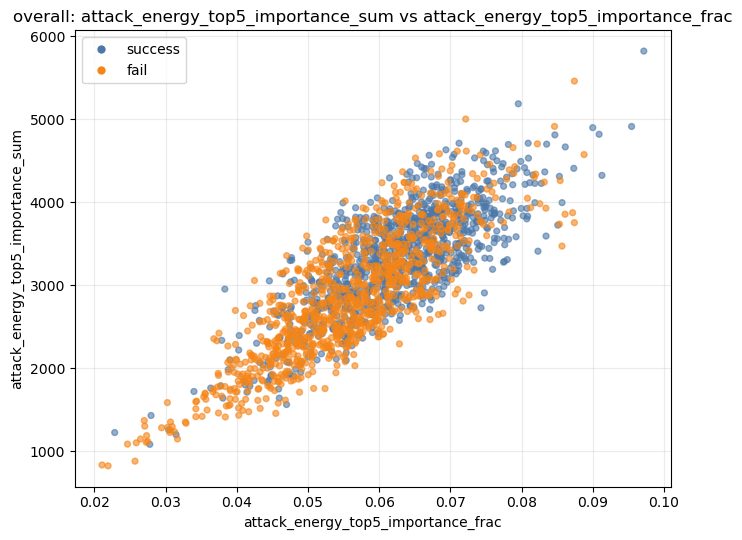

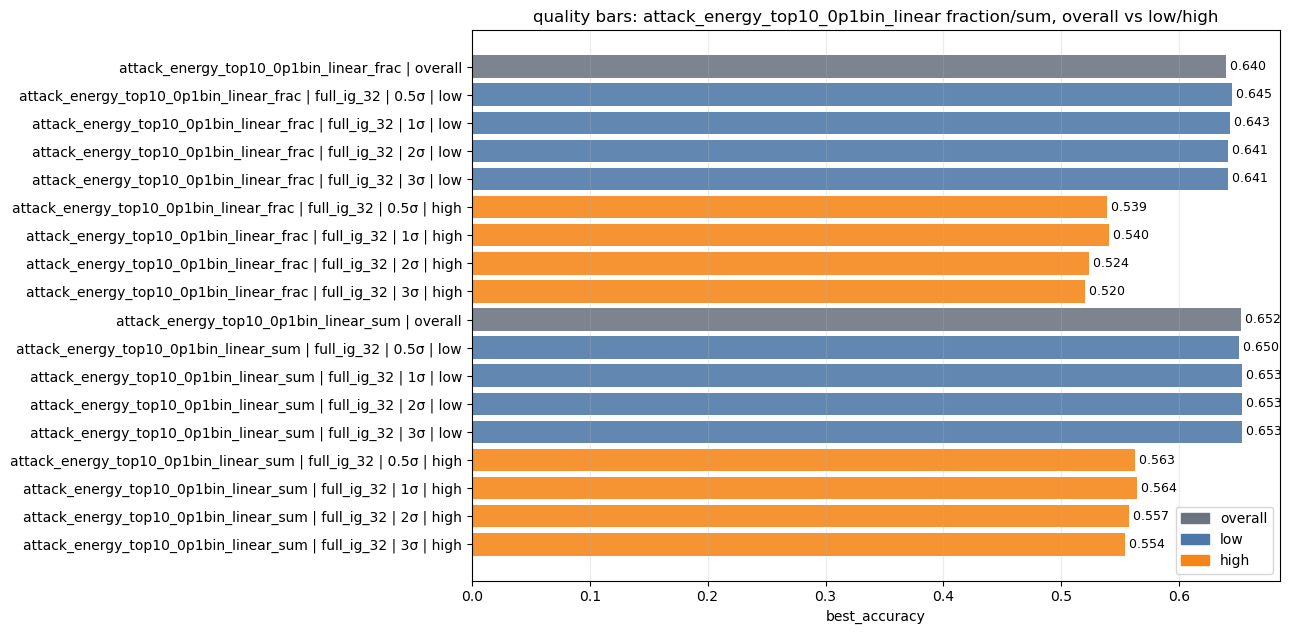

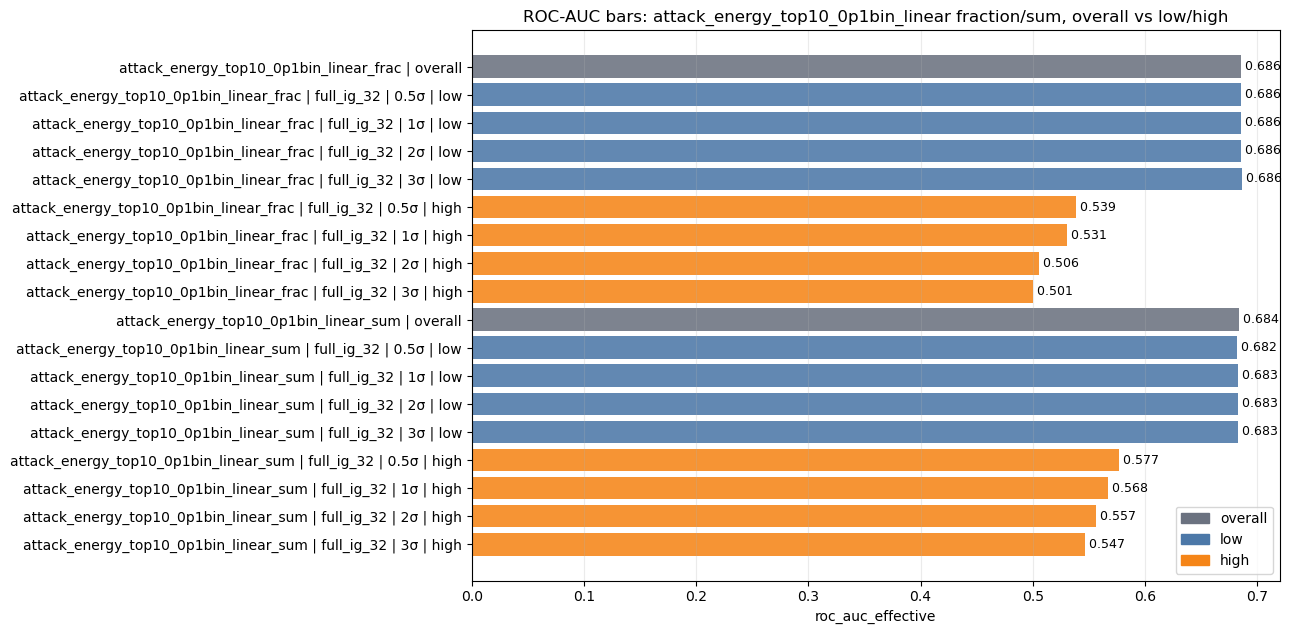

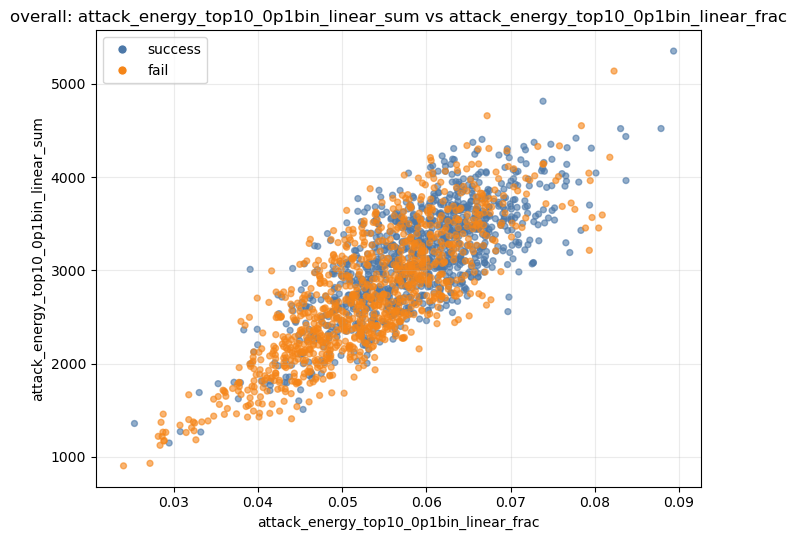

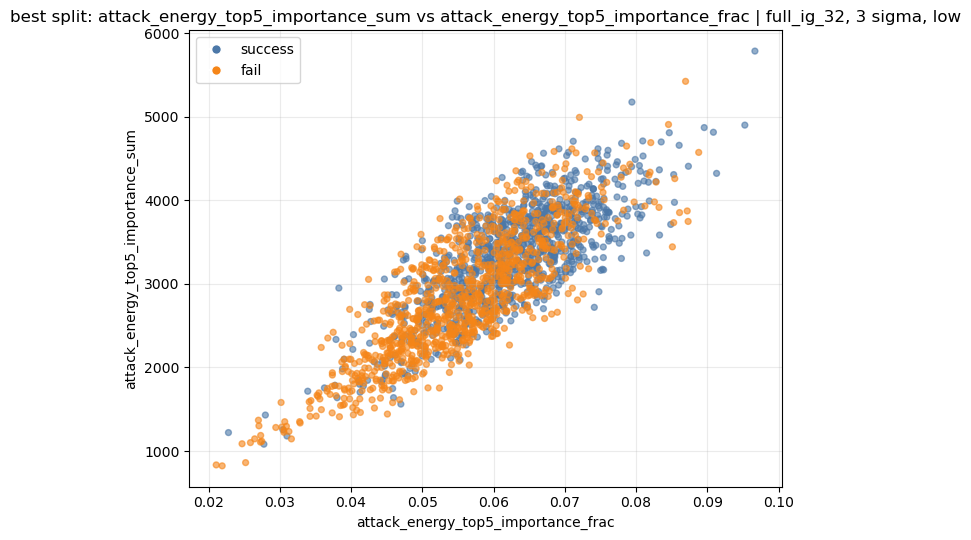

In [15]:
for metric_base in ["attack_energy_top5_importance", "attack_energy_top10_0p1bin_linear"]:
    fig = covariance.plot_focus_quality_comparison_bars(
        focus_quality_comparison,
        score_col="best_accuracy",
        title=f"quality bars: {metric_base} fraction/sum, overall vs low/high",
        metrics=[f"{metric_base}_frac", f"{metric_base}_sum"],
    )
    plt.show()

    fig = covariance.plot_focus_quality_comparison_bars(
        focus_quality_comparison,
        score_col="roc_auc_effective",
        title=f"ROC-AUC bars: {metric_base} fraction/sum, overall vs low/high",
        metrics=[f"{metric_base}_frac", f"{metric_base}_sum"],
    )
    plt.show()

    fig = covariance.plot_focus_raw_vs_fraction(
        focus_overall_rows,
        metric_base=metric_base,
        title=f"overall: {metric_base}_sum vs {metric_base}_frac",
        color_col="success",
    )
    plt.show()

if len(focus_split_quality):
    best_focus = focus_split_quality.iloc[0]
    best_split_rows = cov_split_rows[
        (cov_split_rows["cov_method"].astype(str) == str(best_focus["cov_method"]))
        & (cov_split_rows["sigma"].astype(float) == float(best_focus["sigma"]))
        & (cov_split_rows["cov_group"].astype(str) == str(best_focus["cov_group"]))
    ]
    metric = str(best_focus["metric"])
    if metric.endswith("_frac"):
        metric_base = metric[: -len("_frac")]
    elif metric.endswith("_sum"):
        metric_base = metric[: -len("_sum")]
    else:
        metric_base = "attack_energy_top5_importance"
    fig = covariance.plot_focus_raw_vs_fraction(
        best_split_rows,
        metric_base=metric_base,
        title=(
            f"best split: {metric_base}_sum vs {metric_base}_frac | "
            f"{best_focus['cov_method']}, {float(best_focus['sigma']):g} sigma, {best_focus['cov_group']}"
        ),
        color_col="success",
    )
    plt.show()

## Threshold sweep: optimize split threshold

Перебираем много логичных `|covariance|`-порогов для `full_ig_32`: `mean+kσ`, quantiles по ненулевым значениям и top-fraction thresholds. Для каждого порога считаем focused-метрики отдельно в low/high группе и ранжируем результаты двумя способами: по best accuracy для success/fail и по похожести на `drop` в регрессии.

,threshold_kind,threshold_label,threshold,source_value,mean_abs_nonzero,std_abs_nonzero,nonzero_count,total_count,zero_frac
0,quantile,q50,0.001198,50.00,0.01097,0.165825,25140193.0,409395200.0,0.938592
1,quantile,q60,0.002129,60.00,0.01097,0.165825,25140193.0,409395200.0,0.938592
2,quantile,q70,0.003832,70.00,0.01097,0.165825,25140193.0,409395200.0,0.938592
3,quantile,q75,0.005257,75.00,0.01097,0.165825,25140193.0,409395200.0,0.938592
4,quantile,q80,0.007416,80.00,0.01097,0.165825,25140193.0,409395200.0,0.938592
5,sigma,mean+0sigma,0.010970,0.00,0.01097,0.165825,25140193.0,409395200.0,0.938592
6,quantile,q85,0.011002,85.00,0.01097,0.165825,25140193.0,409395200.0,0.938592
7,quantile,q90,0.017914,90.00,0.01097,0.165825,25140193.0,409395200.0,0.938592
8,quantile,q92.5,0.024490,92.50,0.01097,0.165825,25140193.0,409395200.0,0.938592
9,quantile,q95,0.036713,95.00,0.01097,0.165825,25140193.0,409395200.0,0.938592


cov threshold sweep focus:   0%|          | 0/2000 [00:00<?, ?img/s]

loaded_from_cache=False
cache_path=new_experiments/outputs/patch_success_analysis/cache/covariance_threshold_sweep_focus/covariance_threshold_sweep_focus_b345893ecaac22e3.pkl
rows=119940, candidates=30, classification rows=240, regression rows=240, skipped=1


,path,reason
0,../datasets/COCO_people/03520_train2017_image1...,missing covariance row


Best thresholds by classification accuracy


,metric,roc_auc,best_accuracy,best_threshold,best_direction,cov_method,threshold_id,threshold_kind,threshold_label,threshold,cov_group,roc_auc_effective
0,attack_energy_top5_importance_sum,0.687512,0.653827,2897.840913,1,full_ig_32,25,sigma,mean+2.5sigma,0.425532,low,0.687512
1,attack_energy_top5_importance_sum,0.687163,0.653827,2894.429195,1,full_ig_32,19,sigma,mean+1.25sigma,0.218251,low,0.687163
2,attack_energy_top5_importance_sum,0.687140,0.653827,2897.299544,1,full_ig_32,20,quantile,q99.5,0.237549,low,0.687140
3,attack_energy_top5_importance_sum,0.687077,0.653827,2893.621888,1,full_ig_32,17,quantile,q99.2,0.168701,low,0.687077
4,attack_energy_top5_importance_sum,0.687658,0.653327,2903.404045,1,full_ig_32,27,sigma,mean+4sigma,0.674269,low,0.687658
5,attack_energy_top5_importance_sum,0.687609,0.653327,2900.572881,1,full_ig_32,26,sigma,mean+3sigma,0.508444,low,0.687609
6,attack_energy_top5_importance_sum,0.687469,0.653327,2901.834946,1,full_ig_32,23,sigma,mean+2sigma,0.342619,low,0.687469
7,attack_energy_top5_importance_sum,0.687464,0.653327,2901.557846,1,full_ig_32,22,quantile,q99.7,0.341553,low,0.687464
8,attack_energy_top5_importance_sum,0.687439,0.653327,2898.929580,1,full_ig_32,24,top_fraction,top0.25pct,0.387451,low,0.687439
9,attack_energy_top5_importance_sum,0.687250,0.653327,2894.605404,1,full_ig_32,21,sigma,mean+1.5sigma,0.259707,low,0.687250


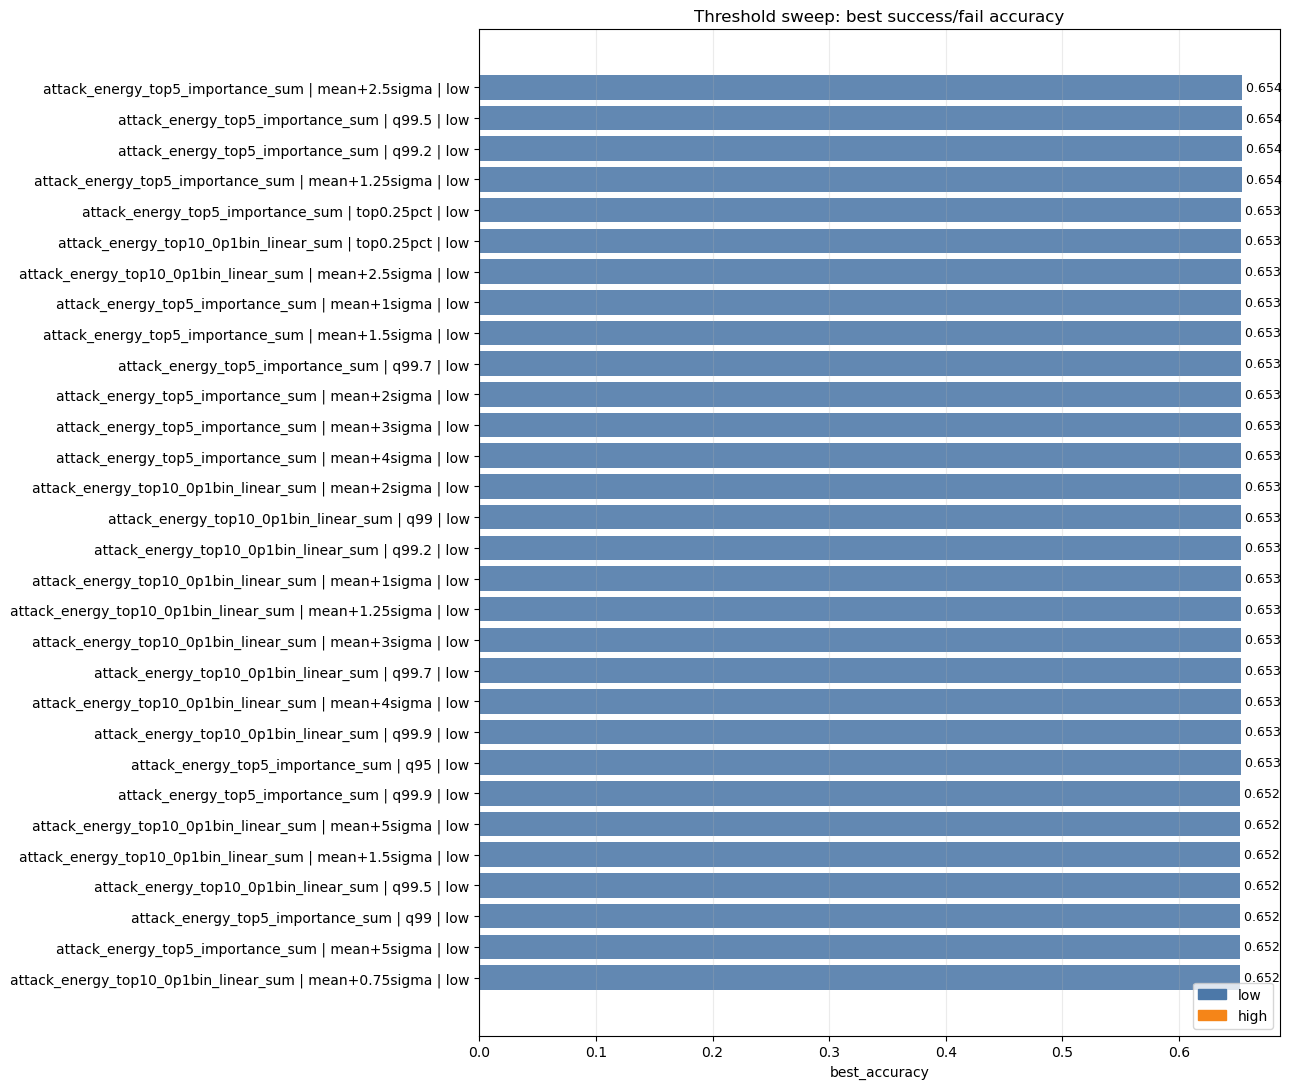

Best thresholds by drop-regression similarity


,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score,cov_method,threshold_id,threshold_kind,threshold_label,threshold,cov_group
0,attack_energy_top5_importance_sum,1999,1.0,0.279151,0.278846,0.196834,0.279151,0.278846,0.196834,0.184843,...,0.960247,1.000000,0.510140,0.376196,full_ig_32,10,sigma,mean+0.25sigma,0.052426,low
1,attack_energy_top10_0p1bin_linear_sum,1999,1.0,0.278261,0.276961,0.196119,0.278261,0.276961,0.196119,0.197075,...,0.960505,1.000000,0.510073,0.375563,full_ig_32,29,sigma,mean+5sigma,0.840094,low
2,attack_energy_top10_0p1bin_linear_sum,1999,1.0,0.278221,0.276875,0.196047,0.278221,0.276875,0.196047,0.196534,...,0.960517,1.000000,0.510070,0.375534,full_ig_32,28,quantile,q99.9,0.739258,low
3,attack_energy_top10_0p1bin_linear_sum,1999,1.0,0.278164,0.276803,0.195979,0.278164,0.276803,0.195979,0.198731,...,0.960533,1.000000,0.510065,0.375503,full_ig_32,27,sigma,mean+4sigma,0.674269,low
4,attack_energy_top10_0p1bin_linear_sum,1999,1.0,0.278079,0.276708,0.195878,0.278079,0.276708,0.195878,0.200399,...,0.960558,1.000000,0.510059,0.375445,full_ig_32,26,sigma,mean+3sigma,0.508444,low
5,attack_energy_top10_0p1bin_linear_sum,1999,1.0,0.277824,0.276404,0.195579,0.277824,0.276404,0.195579,0.195147,...,0.960632,1.000000,0.510040,0.375272,full_ig_32,25,sigma,mean+2.5sigma,0.425532,low
6,attack_energy_top10_0p1bin_linear_sum,1999,1.0,0.277723,0.276249,0.195449,0.277723,0.276249,0.195449,0.195174,...,0.960661,1.000000,0.510032,0.375183,full_ig_32,24,top_fraction,top0.25pct,0.387451,low
7,attack_energy_top5_importance_sum,1999,1.0,0.277562,0.277218,0.195538,0.277562,0.277218,0.195538,0.184947,...,0.960708,1.000000,0.510020,0.375149,full_ig_32,9,quantile,q95,0.036713,low
8,attack_energy_top10_0p1bin_linear_sum,1999,1.0,0.277649,0.276217,0.195414,0.277649,0.276217,0.195414,0.194901,...,0.960683,1.000000,0.510026,0.375138,full_ig_32,22,quantile,q99.7,0.341553,low
9,attack_energy_top10_0p1bin_linear_sum,1999,1.0,0.277645,0.276216,0.195425,0.277645,0.276216,0.195425,0.193980,...,0.960684,1.000000,0.510026,0.375138,full_ig_32,23,sigma,mean+2sigma,0.342619,low


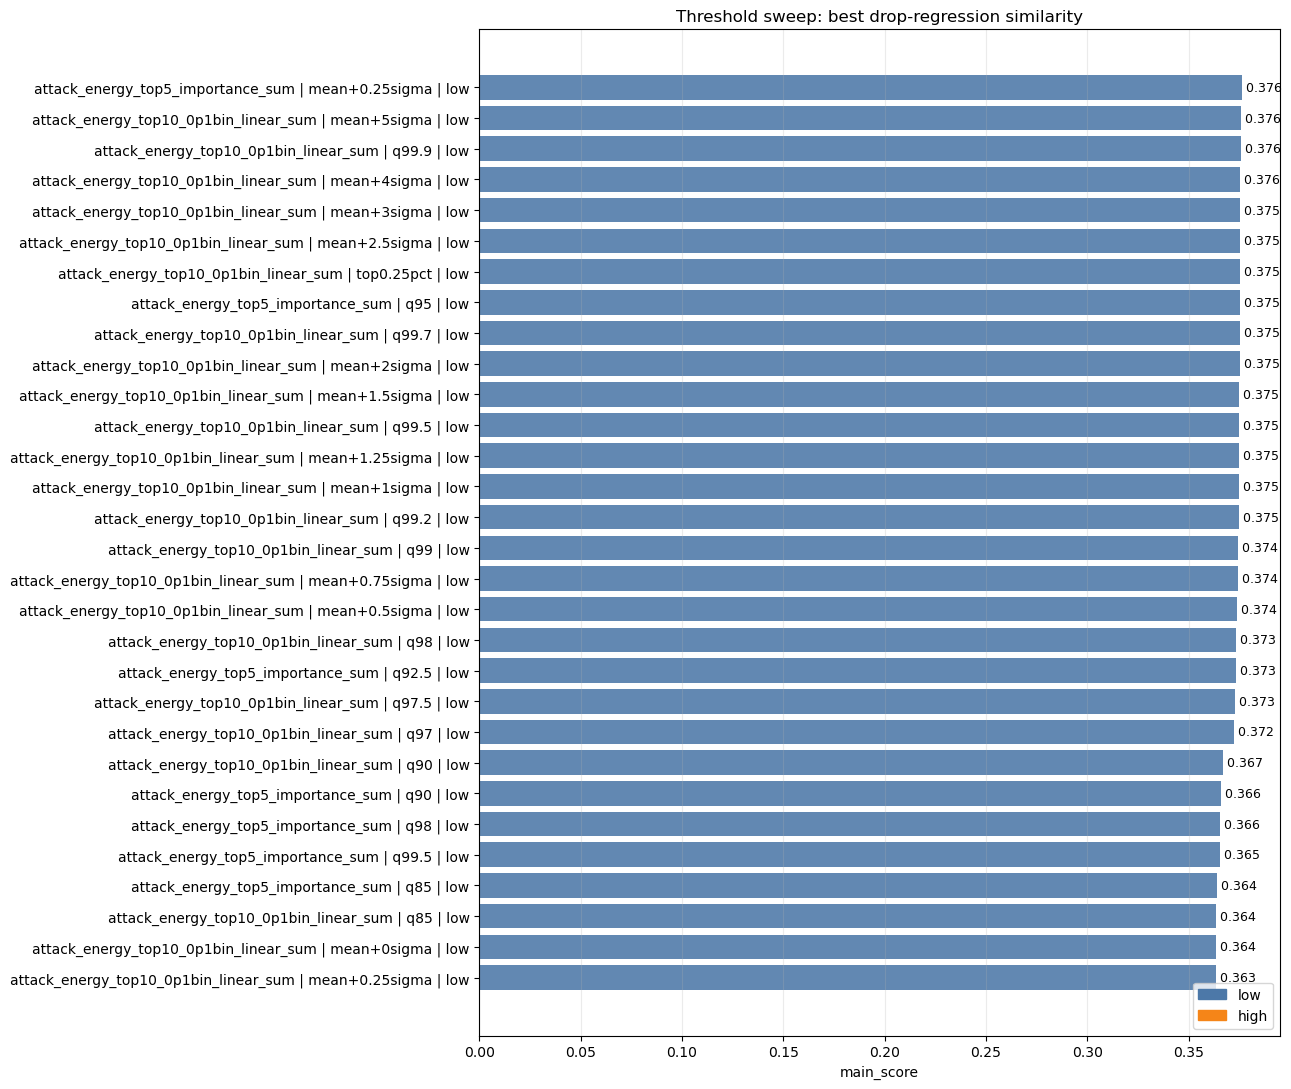

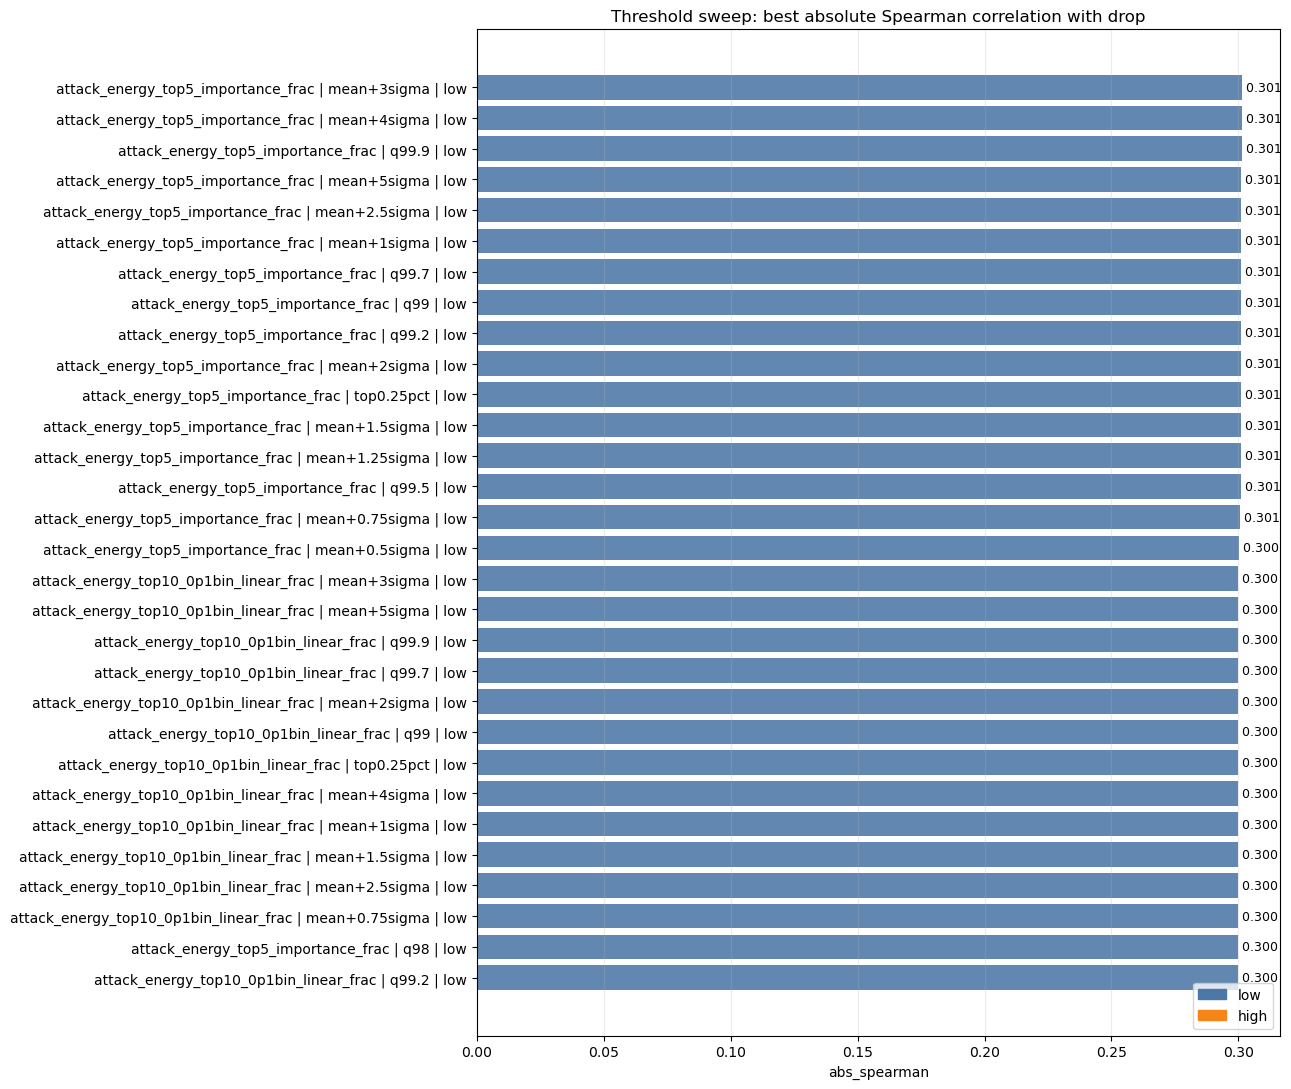

In [16]:
if "cov_rows_full_ig_32" not in globals():
    cov_rows_full_ig_32 = cov_rows[cov_rows["method"].astype(str) == "full_ig_32"].copy()
if cov_rows_full_ig_32.empty:
    raise RuntimeError("No full_ig_32 covariance rows found. Run the covariance compute cell for full_ig_32 first.")

threshold_candidates = covariance.covariance_threshold_candidate_table(
    cov_rows_full_ig_32,
    sigmas=(0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0),
    quantiles=(50.0, 60.0, 70.0, 75.0, 80.0, 85.0, 90.0, 92.5, 95.0, 97.0, 97.5, 98.0, 99.0, 99.2, 99.5, 99.7, 99.9),
    top_fractions=(0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0),
    sample_per_image=20000,
    seed=17,
    zero_eps=0.0,
)
display(threshold_candidates)

threshold_sweep_result = covariance.compute_or_load_covariance_threshold_sweep_focus(
    exp,
    cov_rows_full_ig_32,
    selected_examples,
    layer_name=config.target_layer,
    candidates=threshold_candidates,
    metric_cols=tuple(focus_metric_cols),
    sample_per_image=20000,
    seed=17,
    zero_eps=0.0,
    force=False,
)
threshold_sweep_rows = threshold_sweep_result["rows"]
threshold_sweep_classification = threshold_sweep_result["classification"]
threshold_sweep_regression = threshold_sweep_result["regression"]
threshold_sweep_skipped = threshold_sweep_result["skipped"]

print("loaded_from_cache=" + str(threshold_sweep_result["loaded_from_cache"]))
print("cache_path=" + str(threshold_sweep_result["cache_path"]))
print(
    f"rows={len(threshold_sweep_rows)}, candidates={len(threshold_candidates)}, "
    f"classification rows={len(threshold_sweep_classification)}, regression rows={len(threshold_sweep_regression)}, "
    f"skipped={len(threshold_sweep_skipped)}"
)
if len(threshold_sweep_skipped):
    display(threshold_sweep_skipped.head(20))

print("Best thresholds by classification accuracy")
display(threshold_sweep_classification.head(30))
fig = covariance.plot_threshold_sweep_top_bars(
    threshold_sweep_classification,
    score_col="best_accuracy",
    top_n=30,
    title="Threshold sweep: best success/fail accuracy",
)
plt.show()

print("Best thresholds by drop-regression similarity")
display(threshold_sweep_regression.head(30))
fig = covariance.plot_threshold_sweep_top_bars(
    threshold_sweep_regression,
    score_col="main_score",
    top_n=30,
    title="Threshold sweep: best drop-regression similarity",
)
plt.show()

fig = covariance.plot_threshold_sweep_top_bars(
    threshold_sweep_regression,
    score_col="abs_spearman",
    top_n=30,
    title="Threshold sweep: best absolute Spearman correlation with drop",
)
plt.show()